### ML model to learn bandgap Property of polymers using different featurization methods

In this tutorial we will learn about different ways to develop features of polymers (or molecular and organic) systems.  The different types of features will be visualized and used to create ML models (Random forest) to predict bandgap property of polymers. We will go through the following steps:

1. Read polymer datafile and re-structure it for ML use
2. Visualize a few polymers
3. Understanding Morgan Fingerprint for a particular Polymer SMILE
4. Compute morgan fingerprint for all polymer smiles
5. Polymer ML model training
6. Improving performance by feature engineering
7. Adding more descriptors to improve model performance
8. Combining Morgan Fingerprint and Molecular Descriptors to improve model performance

The dataset for this tutorial is taken from the following publication:

Kuenneth, Christopher, et al. "Polymer informatics with multi-task learning." Patterns 2.4 (2021). (https://doi.org/10.1016/j.patter.2021.100238)

### 0. Import python libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt  # To visualize data
import numpy as np
from tqdm import tqdm

In [ ]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFECV

In [ ]:
!pip install rdkit

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [ ]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem import Draw, AllChem
from rdkit.Chem import Lipinski, GraphDescriptors

#### Define additional utility functions

In [ ]:
# First we will define function to make plots. This will make the code simpler.

def polt_parity(y_cv_test,y_pred_test, y_cv_train=None,y_pred_train=None, label=None, ylim=[50,900]):
    """
    Function to make parity plots.
    """

    # Plot Parity plot
    rmse_test = np.sqrt(mean_squared_error(y_cv_test,y_pred_test))
    r2_test = r2_score(y_cv_test,y_pred_test)

    if y_cv_train is None:
        fig, ax1 = plt.subplots(nrows=1, ncols=1, figsize=(5,4), sharey=True, sharex=True)
    else:
        fig, (ax1,ax2) = plt.subplots(nrows=1, ncols=2, figsize=(9,4), sharey=True, sharex=True)

    ax1.scatter(y_cv_test,y_pred_test)
    ax1.text(0.95, 0.26, label, transform=ax1.transAxes, ha='right', fontsize=14)
    ax1.text(0.95, 0.18, "RMSE: %.2f"%rmse_test, transform=ax1.transAxes, ha='right', fontsize=14)
    ax1.text(0.95, 0.1, "R$^2$: %.2f"%r2_test, transform=ax1.transAxes, ha='right', fontsize=14)
    ax1.plot(ylim, ylim, '--k')
    ax1.set_xlabel('True y', fontsize=14)
    ax1.set_ylabel('Pred y', fontsize=14)
    ax1.set_xlim(ylim[0],ylim[1])
    ax1.set_ylim(ylim[0],ylim[1])

    if y_cv_train is not None:
        rmse_train = np.sqrt(mean_squared_error(y_cv_train,y_pred_train))
        r2_train = r2_score(y_cv_train,y_pred_train)

        ax2.scatter(y_cv_train,y_pred_train, c='m')
        ax2.text(0.95, 0.26, "Train", transform=ax2.transAxes, ha='right', fontsize=14)
        ax2.text(0.95, 0.18, "RMSE: %.2f"%rmse_train, transform=ax2.transAxes, ha='right', fontsize=14)
        ax2.text(0.95, 0.1, "R2: %.2f"%r2_train, transform=ax2.transAxes, ha='right', fontsize=14)
        ax2.plot(ylim, ylim, '--k')

        ax2.set_xlabel('True y', fontsize=14)
        ax2.set_xlim(ylim[0],ylim[1])
        ax2.set_ylim(ylim[0],ylim[1])

    plt.tight_layout()
    plt.show()

    return None

### 1. Download, read and structure the polymer data for ML

In [ ]:
!gdown 1L3vhIpyXKddSRvnj3VojP8DSrBeAeNB2

Downloading...
From: https://drive.google.com/uc?id=1L3vhIpyXKddSRvnj3VojP8DSrBeAeNB2
To: /content/polymer_data.csv
100% 325k/325k [00:00<00:00, 24.8MB/s]


In [ ]:
polymer_data = pd.read_csv('polymer_data.csv', index_col=0)
polymer_data

,smiles,property,value
0,[*]CC([*])C,Eat,-5.14
1,[*]CC([*])F,Eat,-5.18
2,[*]CC([*])(F)F,Eat,-5.21
3,[*]C(F)C([*])(F)F,Eat,-5.11
4,[*]CCC(F)(F)C([*])(F)F,Eat,-5.21
...,...,...,...
6260,[*]C(F)(F)C(F)(F)C(S1)=CC=C1C(S2)=CC=C2[*],eps,4.36
6261,[*]C(F)(F)C(F)(F)C(=O)O[*],eps,3.31
6262,[*]C(F)(F)C(=O)C(F)(F)C(S1)=CC=C1[*],eps,4.05
6263,[*]C(F)(F)C(=O)C(F)(F)C(C=C1)=CC=C1[*],eps,3.57


In [ ]:
dfs = []

for p in polymer_data['property'].unique():
    print(p, (polymer_data['property'] == p).sum())
    df = polymer_data.loc[polymer_data['property'] == p]
    df = df[['smiles','value']]
    df.columns = ['smiles',p]
    dfs.append(df)

Eat 390
Xc 432
Egc 3380
Egb 561
Eea 368
Ei 370
nc 382
eps 382


In [ ]:
### Construct Pandas DataFrame with Egc and Egb properties

pdb = pd.merge(dfs[2], dfs[3], on='smiles', how='outer')
pdb

,smiles,Egc,Egb
0,C(=O)([*])C1=CC=C(C=C1)C(=O)OC1=CC=C(C=C1)C2(C...,3.8358,NaN
1,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.2146,NaN
2,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.3925,NaN
3,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=C(C(F)(F)F)...,5.3690,NaN
4,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=CC(C(F)(F)F...,5.0879,NaN
...,...,...,...
3393,[*]c8ccc(C7(c4ccc(n3c(=O)c2cc1c(=O)n([*])c(=O)...,2.1924,NaN
3394,[*]c8ccc(C7(c5ccc(n4c(=O)c3ccc(Oc2ccc1c(=O)n([...,3.3847,NaN
3395,[*]c9ccc(C8(c5ccc(n4c(=O)c3ccc(C(=O)c2ccc1c(=O...,2.4589,NaN
3396,[*]n1nc(-n2c(=O)c3cc4c(=O)n([*])c(=O)c4cc3c2=O...,2.9967,NaN


In [ ]:
(pdb['Egc'].isna()).sum(), (~pdb['Egc'].isna()).sum()

(np.int64(18), np.int64(3380))

In [ ]:
(pdb['Egb'].isna()).sum(), (~pdb['Egb'].isna()).sum()

(np.int64(2837), np.int64(561))

In [ ]:
pdb = pdb.drop([1236])   # removing data point without any carbon
pdb = pdb.reset_index(drop=True)
pdb.head(50)

,smiles,Egc,Egb
0,C(=O)([*])C1=CC=C(C=C1)C(=O)OC1=CC=C(C=C1)C2(C...,3.8358,NaN
1,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.2146,NaN
2,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.3925,NaN
3,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=C(C(F)(F)F)...,5.3690,NaN
4,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=CC(C(F)(F)F...,5.0879,NaN
5,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=CC=C2)C3=O,5.3284,NaN
6,C23C(C(=O)N(C1=CC=CC=C1C(F)(F)F)C2=O)C(C=[*])O...,5.2302,NaN
7,O([*])c1ccc(cc1)C(=O)Nc1ccc(cc1)S(=O)(=O)c1ccc...,3.8301,NaN
8,[*]/C=C\C(C#N)C[*],5.3057,NaN
9,[*]=CC2CC(C=[*])C3CN(c1cc(C(F)(F)F)cc(C(F)(F)F...,4.3204,NaN


### 2. Visualize a few polymers

In [ ]:
ms = []
props = []
#for smile, egb, egc in pdb.head(10).values:
for smile, egb, egc in pdb.sample(6, random_state=10).values:
    ms.append(Chem.MolFromSmiles(smile))
    props.append(''.join(['Egb: ', str(egb),'  Egc: ', str(egc)]))

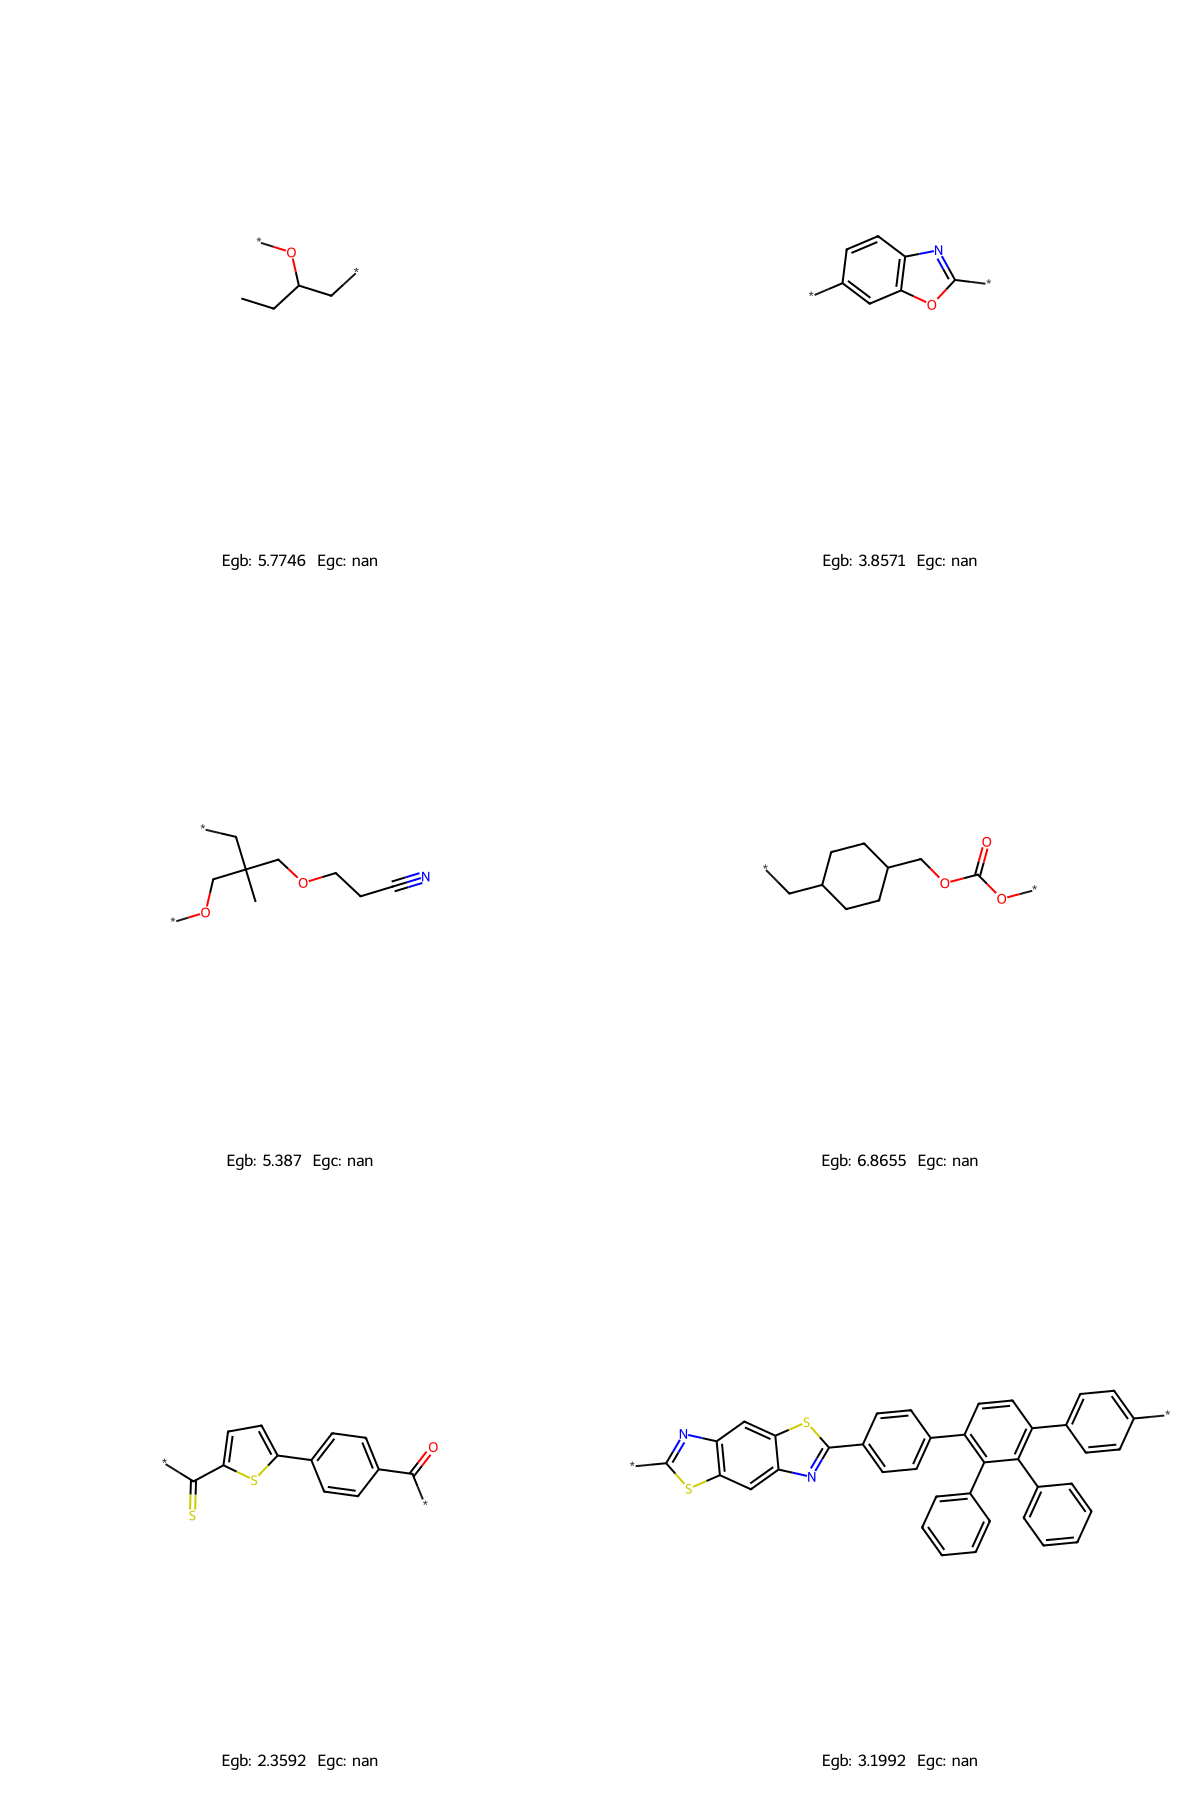

In [ ]:
Draw.MolsToGridImage(ms,molsPerRow=2,subImgSize=(600,600),legends=props)

### 3. Understanding Morgan Fingerprint for a particular Polymer SMILE

In [ ]:
n_dim = 1024
radius = 2

fps_bit = []

smile = pdb['smiles'].values[42]
smile = pdb['smiles'].values[-1]
smile

'c1([*])cc(c2cc1)N=C(N2(C(c2(c3))=O))c1c2c(c4(c3))c(cc1)CN(C4=N2)c(c2cc(c1)([*]))c1'

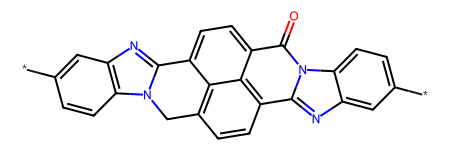

In [ ]:
mol = Chem.MolFromSmiles(smile)
mol

In [ ]:
def mol_with_atom_index(mol):
    """
    Return mol object with atom index for visualization
    """
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(atom.GetIdx())
    return mol

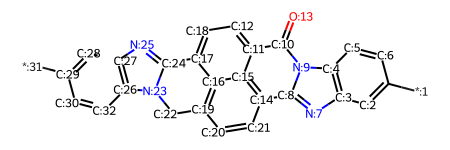

In [ ]:
mol_with_atom_index(mol)

In [ ]:
binfo = {}
fp_bit = AllChem.GetMorganFingerprintAsBitVect(mol,radius,nBits=n_dim, useFeatures=True, bitInfo=binfo)
fp_bit_string = fp_bit.ToBitString()
fp_bit_string

[07:51:25] DEPRECATION WARNING: please use MorganGenerator


'101010100000000010000000000000000000000000000000000000000000000000000000000000000000000000000000100000001000000000000000000000000101000000000000010000000000000000000000000000000000000000000000010010010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000010000000000000000000001000000000000000100000000010000000000000000000010000000001000000000000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000011000001000000000000000000010000000000000000000000000000000000000000000000000100000000000000000000000000000000000000001000000000000000000000000000000000000000000000000000000000000000100001000000000000000000000000001000000000000000000000000000000000000000000000000001000000001000000000000000000000000000000001000000100001000001000000000000000000000000000000000001000000000000001000000000000000000000000000000000000000000000000000000000100000000000000000000000000100000

In [ ]:
fps_bit.append([eval(_) for _ in fp_bit_string])
fps_bit

[[1,
  0,
  1,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  1,
  0,
  0,
  1,


#### Visualize what does each bit represent

In [ ]:
binfo

{0: ((1, 0), (22, 0), (31, 0)),
 2: ((13, 0),),
 4: ((0, 0),
  (2, 0),
  (3, 0),
  (4, 0),
  (5, 0),
  (6, 0),
  (8, 0),
  (10, 0),
  (11, 0),
  (12, 0),
  (14, 0),
  (15, 0),
  (16, 0),
  (17, 0),
  (18, 0),
  (19, 0),
  (20, 0),
  (21, 0),
  (24, 0),
  (26, 0),
  (27, 0),
  (28, 0),
  (29, 0),
  (30, 0),
  (32, 0)),
 6: ((7, 0), (9, 0), (23, 0), (25, 0)),
 16: ((26, 2),),
 96: ((7, 2),),
 104: ((11, 2),),
 129: ((22, 1),),
 131: ((7, 1), (25, 1)),
 145: ((8, 2),),
 193: ((1, 1), (31, 1)),
 196: ((10, 1),),
 199: ((9, 1),),
 349: ((19, 2),),
 371: ((21, 2), (12, 2)),
 387: ((24, 2),),
 397: ((32, 2), (5, 2)),
 418: ((3, 2), (27, 2)),
 428: ((19, 1), (29, 1), (0, 1)),
 476: ((8, 1),),
 532: ((6, 2), (20, 2), (30, 2)),
 533: ((22, 2),),
 539: ((4, 2),),
 559: ((17, 2),),
 609: ((14, 2),),
 650: ((9, 2),),
 714: ((0, 2), (29, 2)),
 719: ((24, 1),),
 746: ((2, 2), (28, 2)),
 797: ((16, 2),),
 806: ((15, 2),),
 839: ((3, 1), (26, 1), (4, 1), (27, 1)),
 846: ((25, 2),),
 851: ((23, 2),),
 8

In [ ]:
tpls1 = [(mol,x, binfo) for x in fp_bit.GetOnBits()]

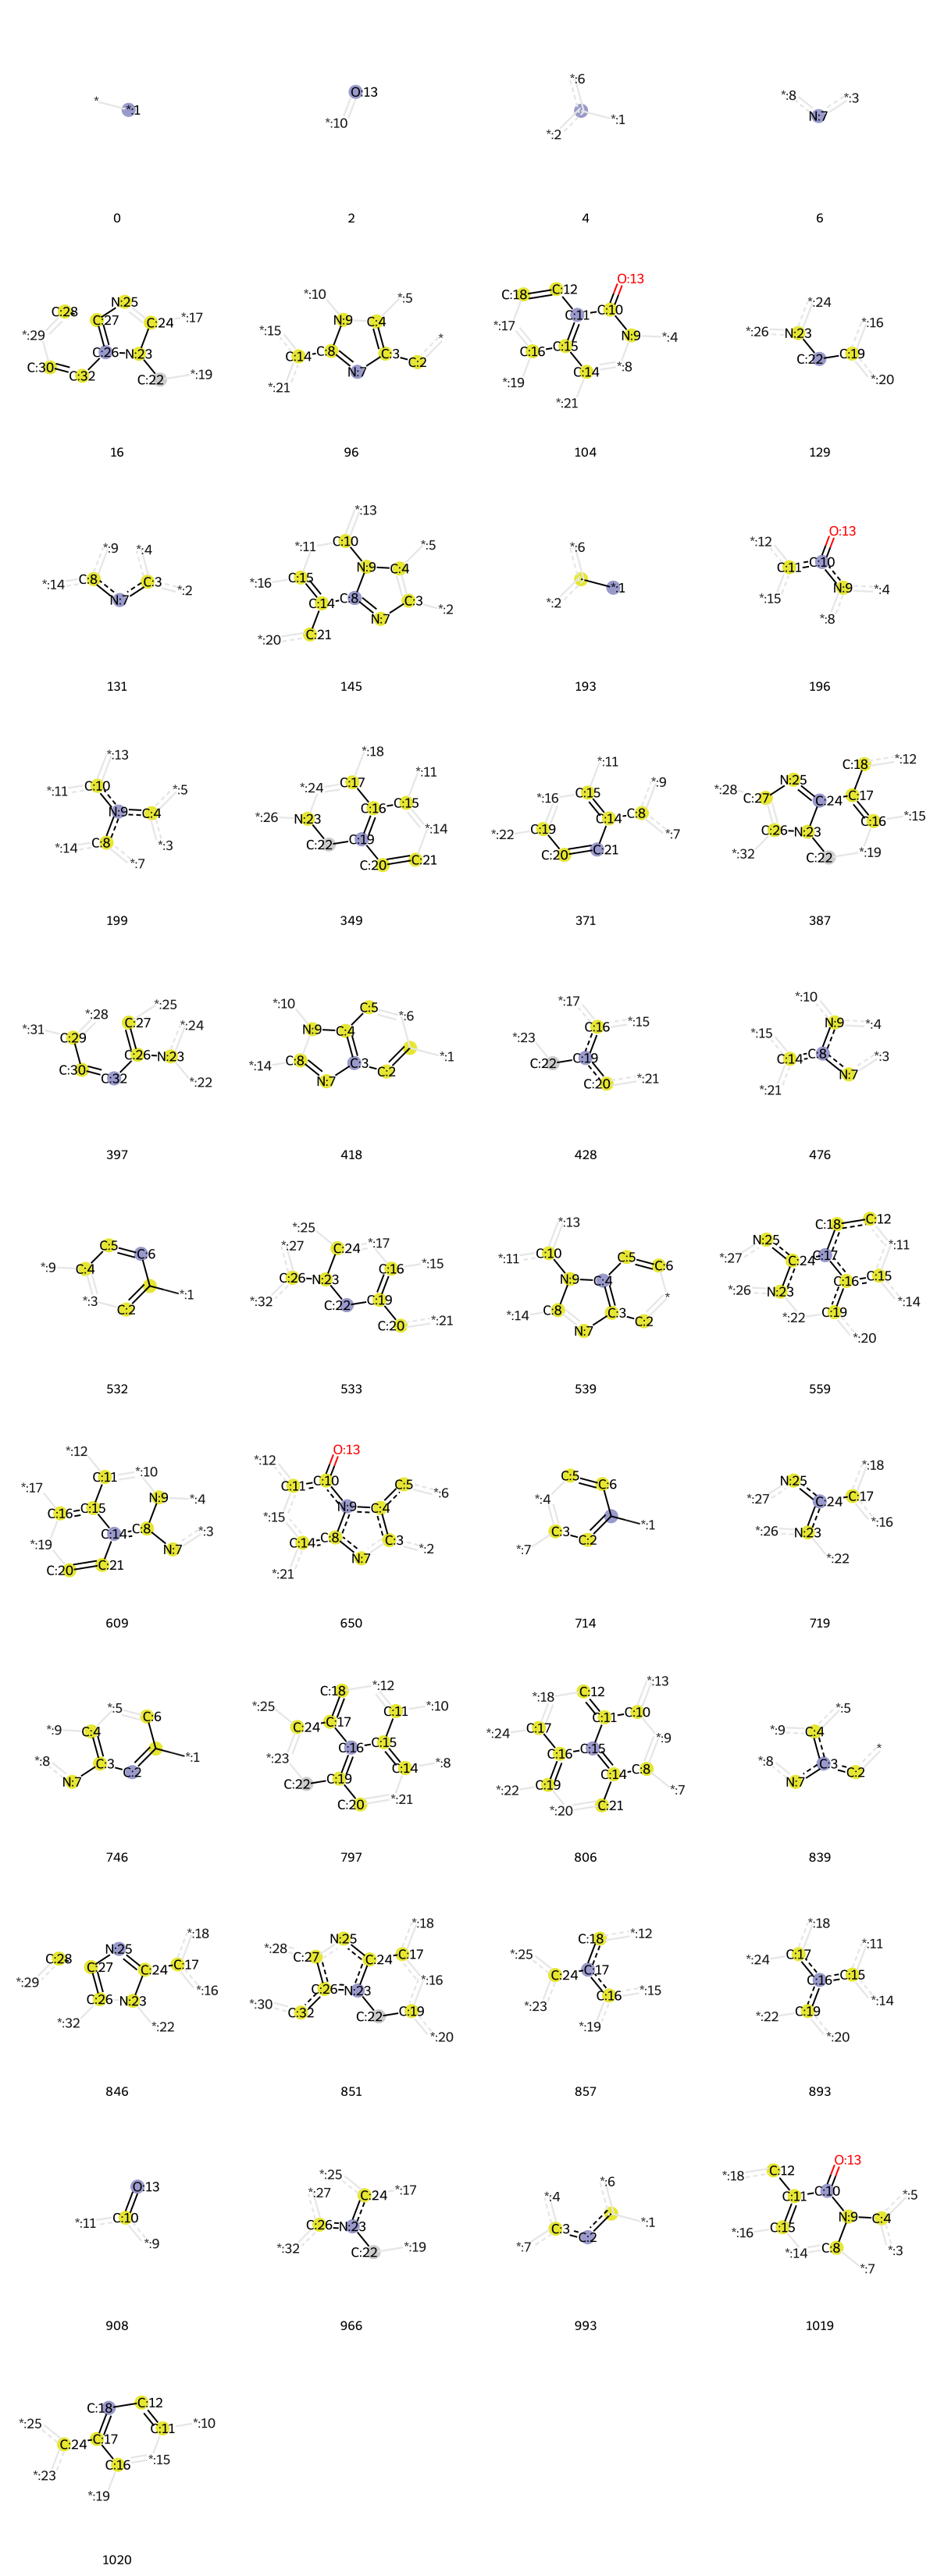

In [ ]:
Draw.DrawMorganBits(tpls1[:],molsPerRow=4,legends=[str(x) for x in fp_bit.GetOnBits()][:],
                    subImgSize=(300, 300), centerColor=(0.6,0.6,0.8))

### 4. Compute morgan fingerprint for all polymer smiles

In [ ]:
fps_bit = []

for smile in tqdm(pdb['smiles'].values):
    mol = Chem.MolFromSmiles(smile)
    fp_bit_string = AllChem.GetMorganFingerprintAsBitVect(mol,radius,nBits=n_dim, useFeatures=True).ToBitString()
    fps_bit.append([eval(_) for _ in fp_bit_string])

  0%|          | 0/3397 [00:00<?, ?it/s][07:51:27] DEPRECATION WARNING: please use MorganGenerator
[07:51:27] DEPRECATION WARNING: please use MorganGenerator
  0%|          | 2/3397 [00:00<03:26, 16.47it/s][07:51:28] DEPRECATION WARNING: please use MorganGenerator
[07:51:28] DEPRECATION WARNING: please use MorganGenerator
  0%|          | 4/3397 [00:00<03:21, 16.80it/s][07:51:28] DEPRECATION WARNING: please use MorganGenerator
[07:51:28] DEPRECATION WARNING: please use MorganGenerator
[07:51:28] DEPRECATION WARNING: please use MorganGenerator
  0%|          | 7/3397 [00:00<02:33, 22.14it/s][07:51:28] DEPRECATION WARNING: please use MorganGenerator
[07:51:28] DEPRECATION WARNING: please use MorganGenerator
[07:51:28] DEPRECATION WARNING: please use MorganGenerator
  0%|          | 10/3397 [00:00<02:33, 22.11it/s][07:51:28] DEPRECATION WARNING: please use MorganGenerator
[07:51:28] DEPRECATION WARNING: please use MorganGenerator
[07:51:28] DEPRECATION WARNING: please use MorganGenerator


In [ ]:
mfp_bit_data = pd.DataFrame(fps_bit)
mfp_bit_data.columns = ['fp_mfpBit_' + str(c) for c in mfp_bit_data.columns]
mfp_bit_data

,fp_mfpBit_0,fp_mfpBit_1,fp_mfpBit_2,fp_mfpBit_3,fp_mfpBit_4,fp_mfpBit_5,fp_mfpBit_6,fp_mfpBit_7,fp_mfpBit_8,fp_mfpBit_9,...,fp_mfpBit_1014,fp_mfpBit_1015,fp_mfpBit_1016,fp_mfpBit_1017,fp_mfpBit_1018,fp_mfpBit_1019,fp_mfpBit_1020,fp_mfpBit_1021,fp_mfpBit_1022,fp_mfpBit_1023
0,1,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,1,0,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
2,1,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3,1,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
4,1,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,1,0,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3393,1,0,1,0,1,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
3394,1,0,1,0,1,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3395,1,0,1,0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
data = pd.concat([pdb, mfp_bit_data], axis=1)
data

,smiles,Egc,Egb,fp_mfpBit_0,fp_mfpBit_1,fp_mfpBit_2,fp_mfpBit_3,fp_mfpBit_4,fp_mfpBit_5,fp_mfpBit_6,...,fp_mfpBit_1014,fp_mfpBit_1015,fp_mfpBit_1016,fp_mfpBit_1017,fp_mfpBit_1018,fp_mfpBit_1019,fp_mfpBit_1020,fp_mfpBit_1021,fp_mfpBit_1022,fp_mfpBit_1023
0,C(=O)([*])C1=CC=C(C=C1)C(=O)OC1=CC=C(C=C1)C2(C...,3.8358,NaN,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.2146,NaN,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
2,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.3925,NaN,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
3,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=C(C(F)(F)F)...,5.3690,NaN,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
4,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=CC(C(F)(F)F...,5.0879,NaN,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,[*]c8ccc(C7(c4ccc(n3c(=O)c2cc1c(=O)n([*])c(=O)...,2.1924,NaN,1,0,1,0,1,0,1,...,0,0,0,0,0,0,1,0,0,0
3393,[*]c8ccc(C7(c5ccc(n4c(=O)c3ccc(Oc2ccc1c(=O)n([...,3.3847,NaN,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
3394,[*]c9ccc(C8(c5ccc(n4c(=O)c3ccc(C(=O)c2ccc1c(=O...,2.4589,NaN,1,0,1,0,1,0,0,...,0,0,1,0,0,0,1,0,0,0
3395,[*]n1nc(-n2c(=O)c3cc4c(=O)n([*])c(=O)c4cc3c2=O...,2.9967,NaN,1,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0


### 5. Time for ML model training

#### We will focus on Egc for now

In [ ]:
egc_data = data.loc[~data['Egc'].isna()]
egc_data = egc_data.sample(frac=1, random_state=42)

In [ ]:
Xcols = egc_data.columns[egc_data.columns.str.contains("fp_mfpBit_")]
X = egc_data[Xcols]

In [ ]:
y = egc_data['Egc']

Text(0, 0.5, 'Frequency')

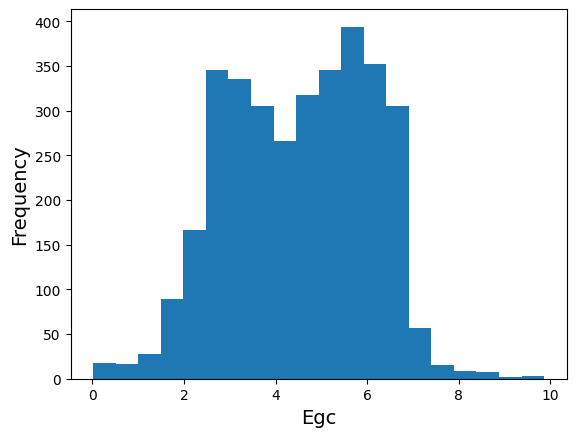

In [ ]:
plt.hist(y.values, bins=20)
plt.xlabel('Egc', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

In [ ]:
X.shape, y.shape

((3379, 1024), (3379,))

#### Remember your lesson on CV for hyper-param optimization

In [ ]:
# Defining the hyperparameter grid
# Here I just define a notional grid; please improve this for actual fitting

param_grid = {
    'n_estimators': [50],
    'max_features': ['sqrt'],
    'max_depth': [None],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

rf = RandomForestRegressor(random_state=42)

In [ ]:
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_search.fit(X, y)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None], 'max_features': ['sqrt'],
                         'min_samples_leaf': [1], 'min_samples_split': [2],
                         'n_estimators': [50]},
             scoring='neg_mean_squared_error', verbose=1)

In [ ]:
# Best parameters found by GridSearchCV
best_params = grid_search.best_params_
print(f"Best parameters found: {best_params}")

Best parameters found: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}


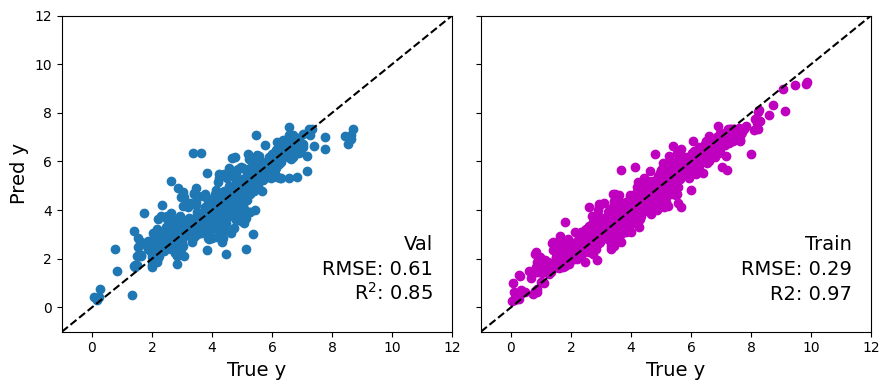

Root Mean squared error: 0.61
Coefficient of determination: 0.85


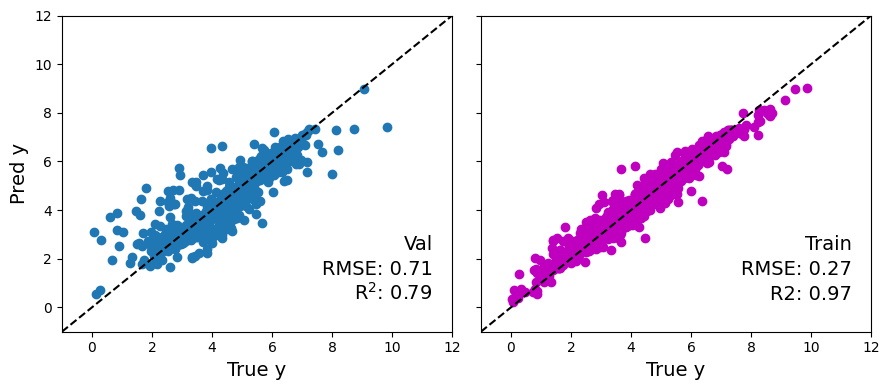

Root Mean squared error: 0.71
Coefficient of determination: 0.79


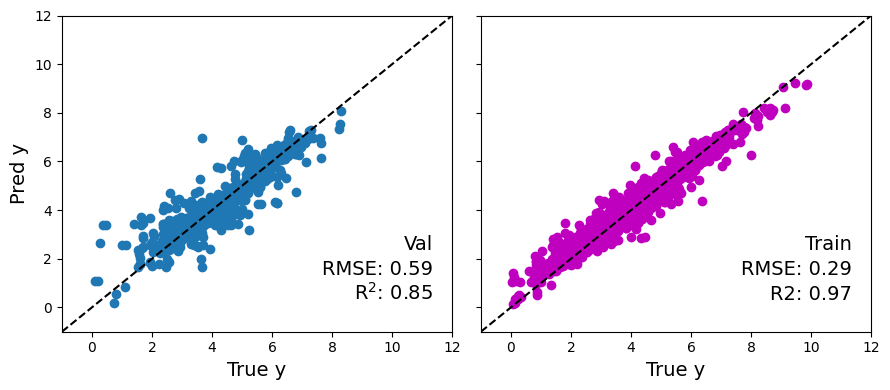

Root Mean squared error: 0.59
Coefficient of determination: 0.85


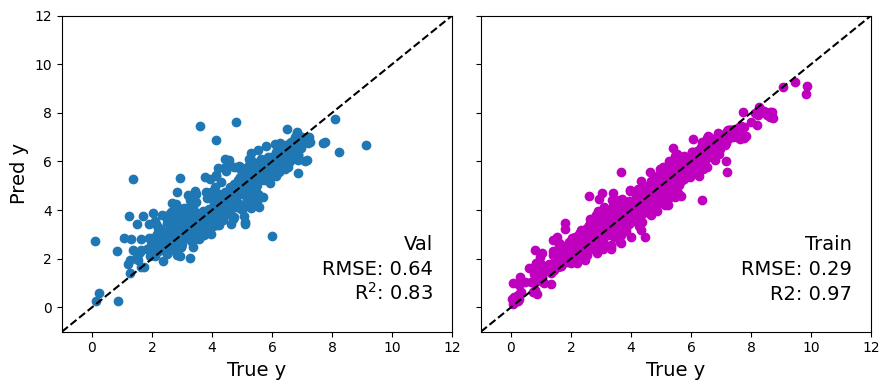

Root Mean squared error: 0.64
Coefficient of determination: 0.83


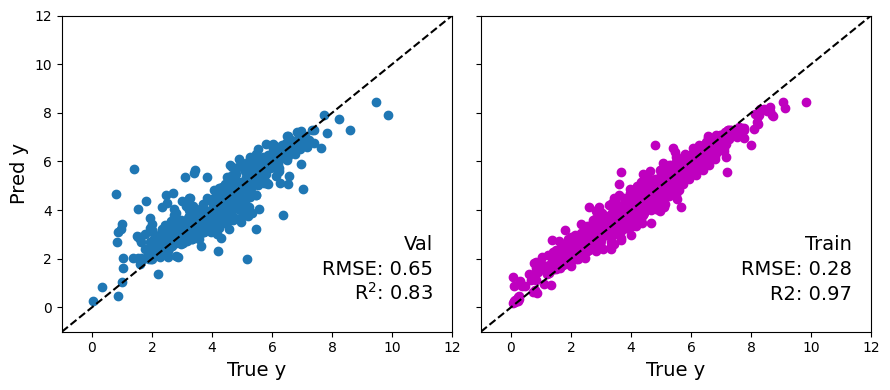

Root Mean squared error: 0.65
Coefficient of determination: 0.83


In [ ]:
#rf_hyp_opt = RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5, min_samples_split=5, n_estimators=100)
rf_hyp_opt = RandomForestRegressor(n_estimators=50, random_state=42)
errors_rf_mfp = []

kf = KFold(n_splits=5)
for idx, (train, val) in enumerate(kf.split(X)):
    X_cv_train = X.values[train]
    X_cv_val = X.values[val]

    y_cv_train = y.values[train]
    y_cv_val = y.values[val]


    # Model fit and prediction
    model = rf_hyp_opt.fit(X_cv_train,y_cv_train)
    y_pred_val = model.predict(X_cv_val)
    y_pred_train = model.predict(X_cv_train)


    # Computing errors
    rmse_val = np.sqrt(mean_squared_error(y_cv_val, y_pred_val))
    rmse_train = np.sqrt(mean_squared_error(y_cv_train, y_pred_train))

    r2_val = r2_score(y_cv_val, y_pred_val)
    r2_train = r2_score(y_cv_train, y_pred_train)


    # Plot Parity plot
    polt_parity(y_cv_val,y_pred_val, y_cv_train,y_pred_train, label="Val", ylim = [-1,12])

    print("Root Mean squared error: %.2f" % rmse_val)
    print("Coefficient of determination: %.2f" % r2_val)

    error = {'kfold': idx+1,
             'rmse_train': rmse_train,
             'rmse_val': rmse_val,
             'r2_val': r2_val,
             'r2_train': r2_train}

    errors_rf_mfp.append(error)
errors_rf_mfp = pd.DataFrame(errors_rf_mfp)

In [ ]:
errors_rf_mfp[['rmse_val','r2_val']].mean()

,0
rmse_val,0.642851
r2_val,0.830062


### 6. Improving performance by feature engineering

#### We will utilize three things:
1. Drop features with zero standard deviation
2. Drop features which are highly correlated
3. Use RFECV to further decrease the number of features

In [ ]:
to_drop = X.columns[(X.std() == 0)]

In [ ]:
X = X.drop(X[to_drop], axis=1)
X

,fp_mfpBit_1,fp_mfpBit_2,fp_mfpBit_3,fp_mfpBit_4,fp_mfpBit_5,fp_mfpBit_6,fp_mfpBit_7,fp_mfpBit_8,fp_mfpBit_10,fp_mfpBit_11,...,fp_mfpBit_1014,fp_mfpBit_1015,fp_mfpBit_1016,fp_mfpBit_1017,fp_mfpBit_1018,fp_mfpBit_1019,fp_mfpBit_1020,fp_mfpBit_1021,fp_mfpBit_1022,fp_mfpBit_1023
405,0,1,0,1,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
321,0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
462,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
885,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1546,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,0,0,1,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1139,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1303,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
866,0,1,0,1,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))

In [ ]:
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

In [ ]:
to_drop

['fp_mfpBit_701',
 'fp_mfpBit_791',
 'fp_mfpBit_862',
 'fp_mfpBit_929',
 'fp_mfpBit_933',
 'fp_mfpBit_993']

In [ ]:
X = X.drop(X[to_drop], axis=1)
X

,fp_mfpBit_1,fp_mfpBit_2,fp_mfpBit_3,fp_mfpBit_4,fp_mfpBit_5,fp_mfpBit_6,fp_mfpBit_7,fp_mfpBit_8,fp_mfpBit_10,fp_mfpBit_11,...,fp_mfpBit_1014,fp_mfpBit_1015,fp_mfpBit_1016,fp_mfpBit_1017,fp_mfpBit_1018,fp_mfpBit_1019,fp_mfpBit_1020,fp_mfpBit_1021,fp_mfpBit_1022,fp_mfpBit_1023
405,0,1,0,1,0,1,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
321,0,0,0,1,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
462,0,0,0,1,0,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
885,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1546,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,0,0,0,1,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1139,0,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
1303,1,1,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
866,0,1,0,1,0,1,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
selector = RFECV(rf_hyp_opt, step=50, cv=3, min_features_to_select=600)

In [ ]:
selector = selector.fit(X, y)

In [ ]:
X = X[selector.get_feature_names_out()]

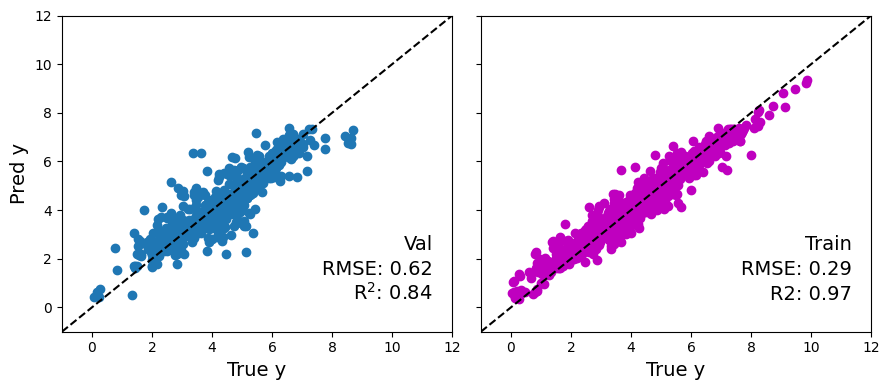

Root Mean squared error: 0.62
Coefficient of determination: 0.84


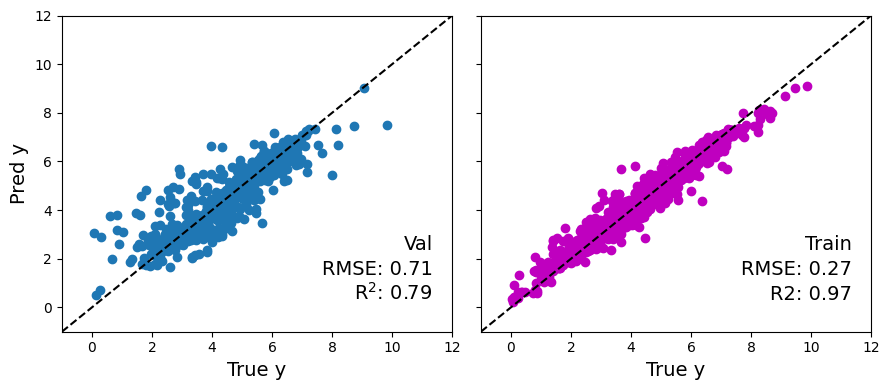

Root Mean squared error: 0.71
Coefficient of determination: 0.79


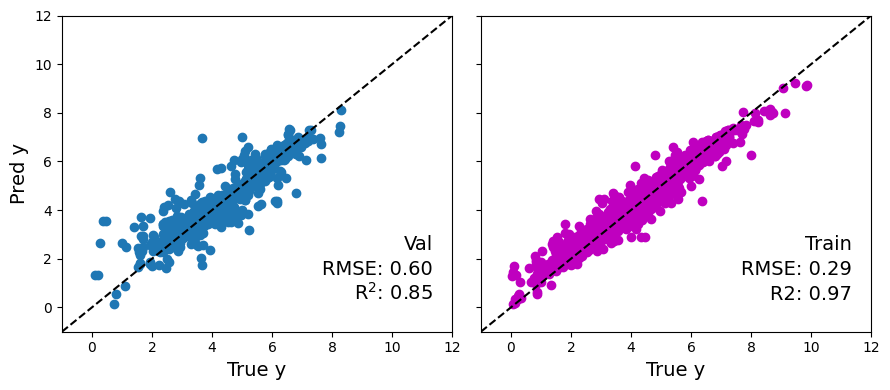

Root Mean squared error: 0.60
Coefficient of determination: 0.85


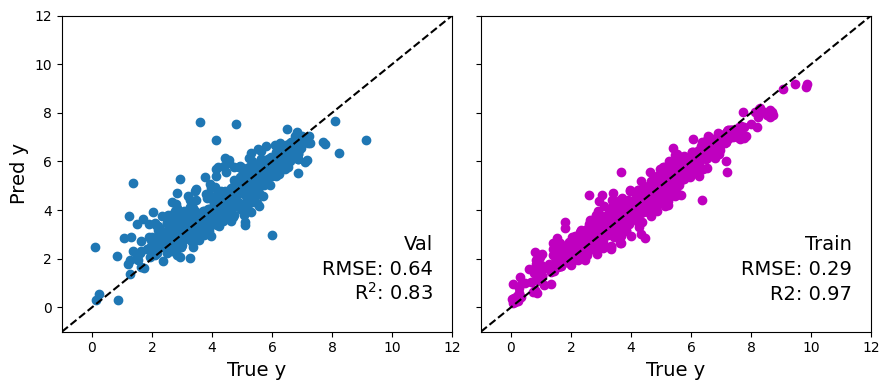

Root Mean squared error: 0.64
Coefficient of determination: 0.83


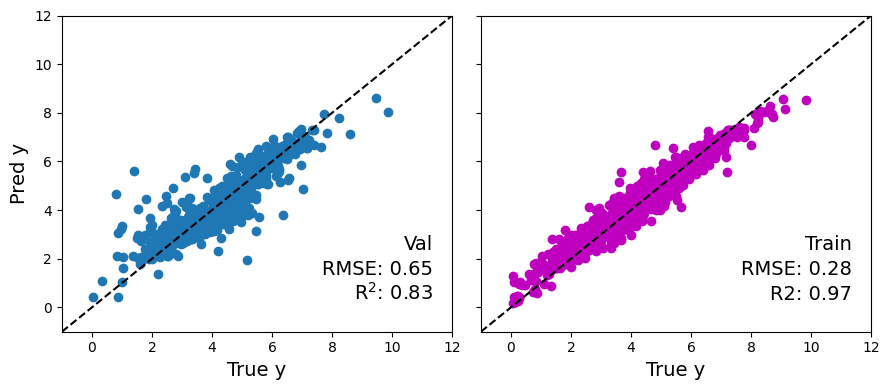

Root Mean squared error: 0.65
Coefficient of determination: 0.83


In [ ]:
#rf_hyp_opt = RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5, min_samples_split=5, n_estimators=100)
rf_hyp_opt = RandomForestRegressor(n_estimators=50, random_state=42)
errors_rf_mfp_fe = []

kf = KFold(n_splits=5)
for idx, (train, val) in enumerate(kf.split(X)):
    X_cv_train = X.values[train]
    X_cv_val = X.values[val]

    y_cv_train = y.values[train]
    y_cv_val = y.values[val]


    # Model fit and prediction
    model = rf_hyp_opt.fit(X_cv_train,y_cv_train)
    y_pred_val = model.predict(X_cv_val)
    y_pred_train = model.predict(X_cv_train)


    # Computing errors
    rmse_val = np.sqrt(mean_squared_error(y_cv_val, y_pred_val))
    rmse_train = np.sqrt(mean_squared_error(y_cv_train, y_pred_train))

    r2_val = r2_score(y_cv_val, y_pred_val)
    r2_train = r2_score(y_cv_train, y_pred_train)


    # Plot Parity plot
    polt_parity(y_cv_val,y_pred_val, y_cv_train,y_pred_train, label="Val", ylim = [-1,12])

    print("Root Mean squared error: %.2f" % rmse_val)
    print("Coefficient of determination: %.2f" % r2_val)

    error = {'kfold': idx+1,
             'rmse_train': rmse_train,
             'rmse_val': rmse_val,
             'r2_val': r2_val,
             'r2_train': r2_train}

    errors_rf_mfp_fe.append(error)
errors_rf_mfp_fe = pd.DataFrame(errors_rf_mfp_fe)

In [ ]:
errors_rf_mfp_fe[['rmse_val','r2_val']].mean()

,0
rmse_val,0.644118
r2_val,0.829432


In [ ]:
X.shape

(3379, 978)

### Question
1. Why reducing features resulted in improvement in model performance?

### 7. Adding more descriptors to improve model performance

#### Rdkit has several cheminformatics based features. We can try combinations of multiple such features. A few are impleted below.

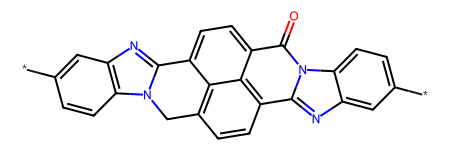

In [ ]:
smile = pdb.smiles.values[-1]
mol = Chem.MolFromSmiles(smile)
mol

In [ ]:

mols_desc = []
MQNs = Chem.rdMolDescriptors.MQNs_(mol)
smr_VSA = Chem.rdMolDescriptors.SMR_VSA_(mol)
slogp_VSA = Chem.rdMolDescriptors.SlogP_VSA_(mol)

o_desc = []
o_desc.append(rdMolDescriptors.CalcNumRotatableBonds(mol))
o_desc.append(Lipinski.RingCount(mol))
o_desc.append(Lipinski.NumAromaticRings(mol))
o_desc.append(Lipinski.NumAliphaticRings(mol))
o_desc.append(GraphDescriptors.Kappa1(mol))
o_desc.append(GraphDescriptors.Kappa2(mol))
o_desc.append(GraphDescriptors.Kappa3(mol))
o_desc.append(GraphDescriptors.Chi0(mol))
o_desc.append(GraphDescriptors.Chi0n(mol))
o_desc.append(GraphDescriptors.Chi0v(mol))
o_desc.append(GraphDescriptors.Chi1(mol))
o_desc.append(GraphDescriptors.Chi1n(mol))
o_desc.append(GraphDescriptors.Chi1v(mol))
o_desc.append(GraphDescriptors.Chi2n(mol))
o_desc.append(GraphDescriptors.Chi2v(mol))
o_desc.append(GraphDescriptors.Chi3n(mol))
o_desc.append(GraphDescriptors.Chi3v(mol))
o_desc.append(GraphDescriptors.Chi4n(mol))
o_desc.append(GraphDescriptors.Chi4v(mol))
o_desc.append(abs(GraphDescriptors.HallKierAlpha(mol)))

mols_desc.append(MQNs + smr_VSA + slogp_VSA + o_desc)

In [ ]:
mols_desc

[[26,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  4,
  1,
  0,
  31,
  2,
  1,
  0,
  20,
  17,
  0,
  0,
  6,
  5,
  0,
  0,
  0,
  0,
  3,
  0,
  0,
  0,
  13,
  17,
  0,
  0,
  0,
  2,
  6,
  0,
  0,
  0,
  0,
  14,
  9,
  0.0,
  0.0,
  18.935751295947565,
  0.0,
  6.544756405912575,
  0.0,
  76.58092625543694,
  0.0,
  11.387855989696924,
  61.391611086015175,
  17.692001031975227,
  18.935751295947565,
  6.544756405912575,
  0.0,
  5.563451491696996,
  65.45820786868792,
  0.0,
  60.64673293878888,
  0.0,
  0.0,
  0.0,
  0.0,
  0,
  8,
  7,
  1,
  13.87797691818671,
  4.418265611596436,
  1.584261601074382,
  np.float64(22.00734273164876),
  16.177712145546504,
  16.177712145546504,
  np.float64(16.080520035918415),
  10.183801430062944,
  10.183801430062944,
  8.110095459239433,
  8.110095459239433,
  6.582441332103153,
  6.582441332103153,
  5.28193908065286,
  5.28193908065286,
  4.249999999999999]]

In [ ]:
mols_desc = []
for smile in tqdm(pdb.smiles.values):
    mol = Chem.MolFromSmiles(smile)
    MQNs = Chem.rdMolDescriptors.MQNs_(mol)
    smr_VSA = Chem.rdMolDescriptors.SMR_VSA_(mol)
    slogp_VSA = Chem.rdMolDescriptors.SlogP_VSA_(mol)

    o_desc = []
    o_desc.append(rdMolDescriptors.CalcNumRotatableBonds(mol))
    o_desc.append(Lipinski.RingCount(mol))
    o_desc.append(Lipinski.NumAromaticRings(mol))
    o_desc.append(Lipinski.NumAliphaticRings(mol))
    o_desc.append(GraphDescriptors.Kappa1(mol))
    o_desc.append(GraphDescriptors.Kappa2(mol))
    o_desc.append(GraphDescriptors.Kappa3(mol))
    o_desc.append(GraphDescriptors.Chi0(mol))
    o_desc.append(GraphDescriptors.Chi0n(mol))
    o_desc.append(GraphDescriptors.Chi0v(mol))
    o_desc.append(GraphDescriptors.Chi1(mol))
    o_desc.append(GraphDescriptors.Chi1n(mol))
    o_desc.append(GraphDescriptors.Chi1v(mol))
    o_desc.append(GraphDescriptors.Chi2n(mol))
    o_desc.append(GraphDescriptors.Chi2v(mol))
    o_desc.append(GraphDescriptors.Chi3n(mol))
    o_desc.append(GraphDescriptors.Chi3v(mol))
    o_desc.append(GraphDescriptors.Chi4n(mol))
    o_desc.append(GraphDescriptors.Chi4v(mol))
    o_desc.append(abs(GraphDescriptors.HallKierAlpha(mol)))

    mols_desc.append(MQNs + smr_VSA + slogp_VSA + o_desc)

100%|██████████| 3397/3397 [00:04<00:00, 682.27it/s]


In [ ]:
mqns_cols = ['fp_mqns_' + str(c) for c in range(1,43)]
smrVsa_cols = ['fp_smrVsa_' + str(c) for c in range(1,11)]
slogPVsa_cols = ['fp_slogPVsa_' + str(c) for c in range(1,13)]

other_desc_cols = ['nRotBon', 'nRing', 'nAroRing', 'nAliRing',
                   'k1','k2','k3', 'chi0', 'chi0n', 'chi0v', 'chi1', 'chi1n', 'chi1v',
                   'chi2n', 'chi2v', 'chi3n', 'chi3v', 'chi4n', 'chi4v', 'HallKierAlpha']
other_desc_cols = ['fp_o_desc_' + str(c) for c in other_desc_cols]

molfp_data = pd.DataFrame(mols_desc, columns=mqns_cols + smrVsa_cols + slogPVsa_cols + other_desc_cols)

In [ ]:
molfp_data

,fp_mqns_1,fp_mqns_2,fp_mqns_3,fp_mqns_4,fp_mqns_5,fp_mqns_6,fp_mqns_7,fp_mqns_8,fp_mqns_9,fp_mqns_10,...,fp_o_desc_chi1,fp_o_desc_chi1n,fp_o_desc_chi1v,fp_o_desc_chi2n,fp_o_desc_chi2v,fp_o_desc_chi3n,fp_o_desc_chi3v,fp_o_desc_chi4n,fp_o_desc_chi4v,fp_o_desc_HallKierAlpha
0,28,0,0,0,0,0,0,0,0,5,...,17.417889,10.424445,10.424445,7.733976,7.733976,5.742751,5.742751,4.100289,4.100289,4.71
1,39,0,0,0,0,1,0,0,0,6,...,23.227586,14.369038,15.852202,10.574579,12.524261,7.881599,9.667135,5.628566,6.889507,5.79
2,34,0,0,0,0,1,0,0,0,7,...,21.628233,12.987394,14.470557,9.708818,11.658500,7.187086,8.972622,5.034321,6.295262,5.54
3,15,3,0,0,0,0,0,0,1,2,...,11.290242,6.432804,6.432804,5.173399,5.173399,3.872966,3.872966,2.808404,2.808404,2.15
4,15,3,0,0,0,0,0,0,1,2,...,11.290242,6.432804,6.432804,5.176854,5.176854,3.851815,3.851815,2.830245,2.830245,2.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,35,0,0,0,0,0,0,0,2,4,...,20.817441,13.136666,13.136666,10.287916,10.287916,8.350673,8.350673,6.608897,6.608897,5.62
3393,36,0,0,0,0,0,0,0,2,6,...,22.667578,13.901304,13.901304,10.636505,10.636505,8.177527,8.177527,6.096430,6.096430,6.35
3394,42,0,0,0,0,0,0,0,2,5,...,24.694452,15.662157,15.662157,12.194391,12.194391,9.756496,9.756496,7.565970,7.565970,6.73
3395,18,0,0,0,0,0,0,0,4,5,...,13.807438,7.767919,7.767919,5.985543,5.985543,4.534322,4.534322,3.275907,3.275907,4.14


### 8. Combining Morgan Fingerprint and Molecular Descriptors to improve model performance

In [ ]:
data = pd.concat([pdb, mfp_bit_data, molfp_data], axis=1)
data

,smiles,Egc,Egb,fp_mfpBit_0,fp_mfpBit_1,fp_mfpBit_2,fp_mfpBit_3,fp_mfpBit_4,fp_mfpBit_5,fp_mfpBit_6,...,fp_o_desc_chi1,fp_o_desc_chi1n,fp_o_desc_chi1v,fp_o_desc_chi2n,fp_o_desc_chi2v,fp_o_desc_chi3n,fp_o_desc_chi3v,fp_o_desc_chi4n,fp_o_desc_chi4v,fp_o_desc_HallKierAlpha
0,C(=O)([*])C1=CC=C(C=C1)C(=O)OC1=CC=C(C=C1)C2(C...,3.8358,NaN,1,0,1,0,1,0,0,...,17.417889,10.424445,10.424445,7.733976,7.733976,5.742751,5.742751,4.100289,4.100289,4.71
1,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.2146,NaN,1,0,1,0,1,0,0,...,23.227586,14.369038,15.852202,10.574579,12.524261,7.881599,9.667135,5.628566,6.889507,5.79
2,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.3925,NaN,1,0,1,0,1,0,0,...,21.628233,12.987394,14.470557,9.708818,11.658500,7.187086,8.972622,5.034321,6.295262,5.54
3,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=C(C(F)(F)F)...,5.3690,NaN,1,0,1,0,1,0,0,...,11.290242,6.432804,6.432804,5.173399,5.173399,3.872966,3.872966,2.808404,2.808404,2.15
4,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=CC(C(F)(F)F...,5.0879,NaN,1,0,1,0,1,0,0,...,11.290242,6.432804,6.432804,5.176854,5.176854,3.851815,3.851815,2.830245,2.830245,2.15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,[*]c8ccc(C7(c4ccc(n3c(=O)c2cc1c(=O)n([*])c(=O)...,2.1924,NaN,1,0,1,0,1,0,1,...,20.817441,13.136666,13.136666,10.287916,10.287916,8.350673,8.350673,6.608897,6.608897,5.62
3393,[*]c8ccc(C7(c5ccc(n4c(=O)c3ccc(Oc2ccc1c(=O)n([...,3.3847,NaN,1,0,1,0,1,0,0,...,22.667578,13.901304,13.901304,10.636505,10.636505,8.177527,8.177527,6.096430,6.096430,6.35
3394,[*]c9ccc(C8(c5ccc(n4c(=O)c3ccc(C(=O)c2ccc1c(=O...,2.4589,NaN,1,0,1,0,1,0,0,...,24.694452,15.662157,15.662157,12.194391,12.194391,9.756496,9.756496,7.565970,7.565970,6.73
3395,[*]n1nc(-n2c(=O)c3cc4c(=O)n([*])c(=O)c4cc3c2=O...,2.9967,NaN,1,0,1,0,1,0,1,...,13.807438,7.767919,7.767919,5.985543,5.985543,4.534322,4.534322,3.275907,3.275907,4.14


In [ ]:
egc_data = data.loc[~data['Egc'].isna()]
egc_data = egc_data.sample(frac=1, random_state=42)

In [ ]:
Xcols = egc_data.columns[egc_data.columns.str.contains("fp_")]
X = egc_data[Xcols]

In [ ]:
y = egc_data['Egc']

In [ ]:
X

,fp_mfpBit_0,fp_mfpBit_1,fp_mfpBit_2,fp_mfpBit_3,fp_mfpBit_4,fp_mfpBit_5,fp_mfpBit_6,fp_mfpBit_7,fp_mfpBit_8,fp_mfpBit_9,...,fp_o_desc_chi1,fp_o_desc_chi1n,fp_o_desc_chi1v,fp_o_desc_chi2n,fp_o_desc_chi2v,fp_o_desc_chi3n,fp_o_desc_chi3v,fp_o_desc_chi4n,fp_o_desc_chi4v,fp_o_desc_HallKierAlpha
405,1,0,1,0,1,0,1,0,0,0,...,14.981200,8.764874,11.881030,6.293697,9.750060,4.530162,8.238070,3.389057,7.163061,2.37
321,1,0,0,0,1,0,1,0,1,0,...,8.709362,4.646228,5.462725,3.329651,4.209304,2.246766,3.113061,1.357781,2.002948,1.36
462,1,0,0,0,1,0,0,0,1,0,...,6.464544,3.182972,3.182972,2.187680,2.187680,1.387968,1.387968,0.856174,0.856174,1.25
885,1,0,1,0,0,0,0,0,0,0,...,5.458543,2.875811,2.875811,2.044420,2.044420,0.724099,0.724099,0.330849,0.330849,1.04
1546,1,1,1,0,0,0,0,0,0,0,...,11.701907,8.968908,8.968908,6.015770,6.015770,3.806623,3.806623,2.426524,2.426524,1.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1102,1,0,0,0,1,0,1,0,0,0,...,6.308862,3.464278,3.464278,2.350501,2.350501,1.618375,1.618375,1.077068,1.077068,1.31
1139,1,0,1,0,0,0,0,0,0,0,...,10.634560,7.765005,7.765005,6.384374,6.384374,4.821468,4.821468,3.280804,3.280804,1.06
1303,1,1,1,0,0,0,0,0,0,0,...,7.308060,5.307678,5.307678,3.501603,3.501603,2.153839,2.153839,1.346217,1.346217,0.53
866,1,0,1,0,1,0,1,0,0,0,...,5.274387,2.330734,3.147230,1.553416,2.721744,0.862836,1.783770,0.487618,1.125585,0.83


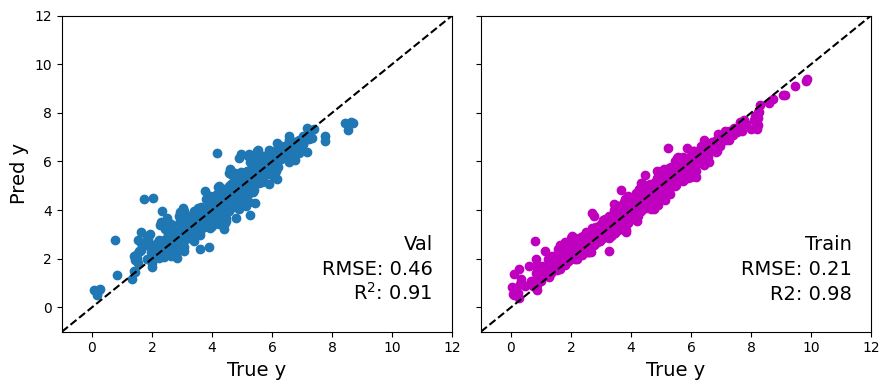

Root Mean squared error: 0.46
Coefficient of determination: 0.91


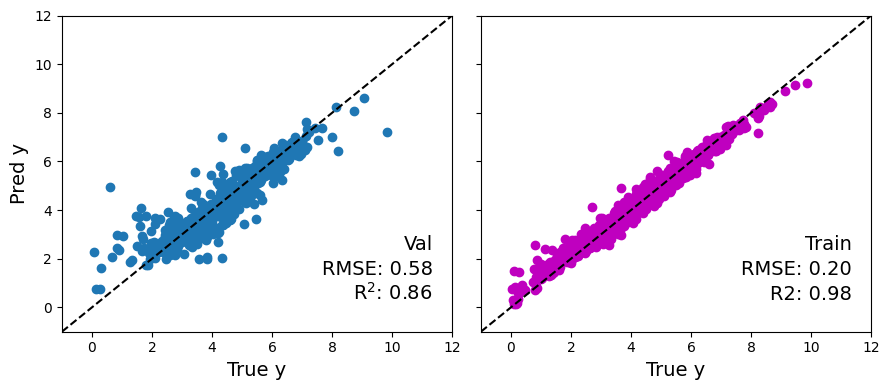

Root Mean squared error: 0.58
Coefficient of determination: 0.86


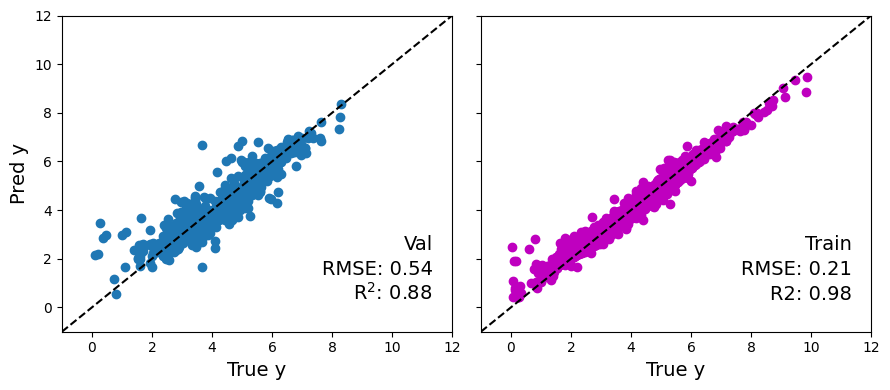

Root Mean squared error: 0.54
Coefficient of determination: 0.88


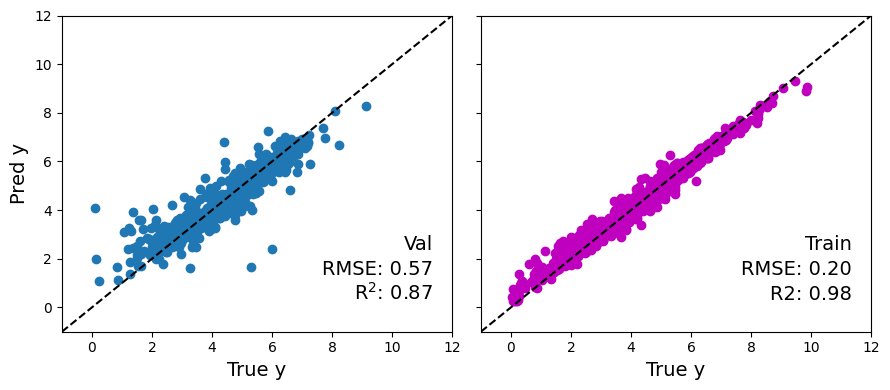

Root Mean squared error: 0.57
Coefficient of determination: 0.87


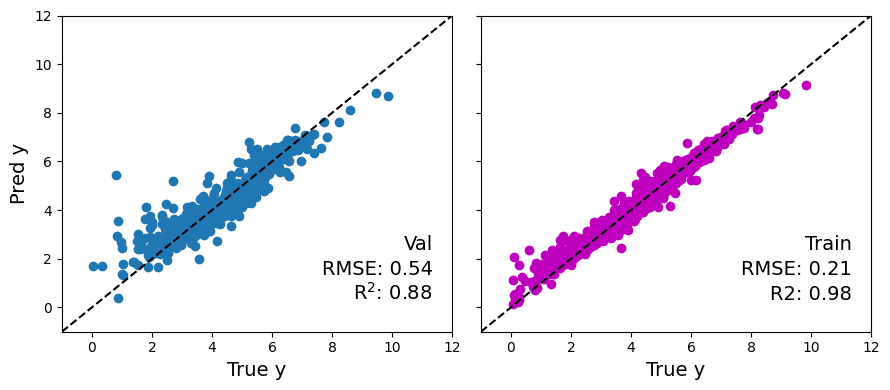

Root Mean squared error: 0.54
Coefficient of determination: 0.88


In [ ]:
#rf_hyp_opt = RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5, min_samples_split=5, n_estimators=100)
rf_hyp_opt = RandomForestRegressor(n_estimators=50)
errors_rf_molfp = []

kf = KFold(n_splits=5)
for idx, (train, val) in enumerate(kf.split(X)):
    X_cv_train = X.values[train]
    X_cv_val = X.values[val]

    y_cv_train = y.values[train]
    y_cv_val = y.values[val]


    # Model fit and prediction
    model = rf_hyp_opt.fit(X_cv_train,y_cv_train)
    y_pred_val = model.predict(X_cv_val)
    y_pred_train = model.predict(X_cv_train)


    # Computing errors
    rmse_val = np.sqrt(mean_squared_error(y_cv_val, y_pred_val))
    rmse_train = np.sqrt(mean_squared_error(y_cv_train, y_pred_train))

    r2_val = r2_score(y_cv_val, y_pred_val)
    r2_train = r2_score(y_cv_train, y_pred_train)


    # Plot Parity plot
    polt_parity(y_cv_val,y_pred_val, y_cv_train,y_pred_train, label="Val", ylim = [-1,12])

    print("Root Mean squared error: %.2f" % rmse_val)
    print("Coefficient of determination: %.2f" % r2_val)

    error = {'kfold': idx+1,
             'rmse_train': rmse_train,
             'rmse_val': rmse_val,
             'r2_val': r2_val,
             'r2_train': r2_train}

    errors_rf_molfp.append(error)
errors_rf_molfp = pd.DataFrame(errors_rf_molfp)

In [ ]:
errors_rf_molfp[['rmse_val','r2_val']].mean()

,0
rmse_val,0.536898
r2_val,0.881156


### Future Exercise
1. Explore Feature engineering and Other fingerprint options for polymers and improve the performance of the model
2. Develop a single model that learns both Egb and Egc properties simultaneously. Would this model be more accurate?

In [ ]:
smiles = ['[*]C[*]', '[*]CC([*])C', '[*]CC([*])n1cc2ccccc2n1']

ms = []
for smile in smiles:
    ms.append(Chem.MolFromSmiles(smile))

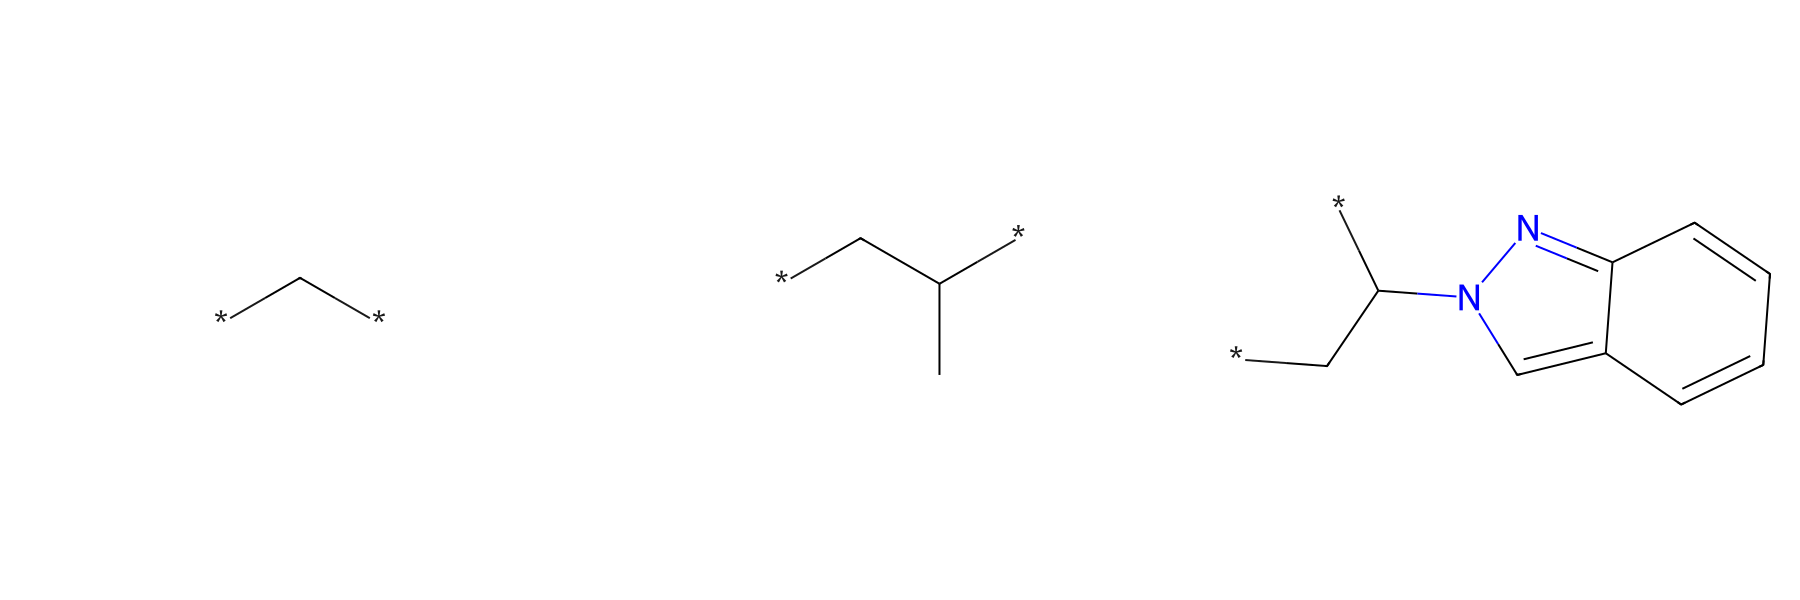

In [ ]:
Draw.MolsToGridImage(ms,molsPerRow=3,subImgSize=(600,600))

### 9. Transformer-based prediction with polyBERT

So far, every feature we've built — Morgan fingerprint bits, RDKit descriptors — was hand-crafted: we decided in advance what chemical patterns to look for. Transformer-based **chemical language models** take a different approach: they treat a polymer's SMILES string as a sentence in a chemical "language," and learn their own representation of it directly from large amounts of unlabeled SMILES data.

We'll use **polyBERT** (Kuenneth & Ramprasad, 2023) — a DeBERTa-based model pretrained on 100 million hypothetical PSMILES strings, released with a ready-to-use pretrained checkpoint, here.

polyBERT was trained on **PSMILES** notation, which uses `[*]` to mark the two points where a repeat unit connects to itself.

In [ ]:
!pip install -q sentence-transformers

#### Let's look at one polymer first

In [ ]:
from sentence_transformers import SentenceTransformer


In [ ]:
'''
from huggingface_hub import login
from getpass import getpass

# Tries a Colab secret named HF_TOKEN first (key icon, left sidebar).
# If none is found, you'll be prompted to paste a token directly instead --
# get a free "Read" token at https://huggingface.co/settings/tokens
try:
    from google.colab import userdata
    hf_token = userdata.get('HF_TOKEN')
except Exception:
    hf_token = None

if not hf_token:
    hf_token = getpass('Enter your Hugging Face token (input hidden): ')

login(hf_token)
print('Logged in to Hugging Face.')
'''

'\nfrom huggingface_hub import login\nfrom getpass import getpass\n\n# Tries a Colab secret named HF_TOKEN first (key icon, left sidebar).\n# If none is found, you\'ll be prompted to paste a token directly instead --\n# get a free "Read" token at https://huggingface.co/settings/tokens\ntry:\n    from google.colab import userdata\n    hf_token = userdata.get(\'HF_TOKEN\')\nexcept Exception:\n    hf_token = None\n\nif not hf_token:\n    hf_token = getpass(\'Enter your Hugging Face token (input hidden): \')\n\nlogin(hf_token)\nprint(\'Logged in to Hugging Face.\')\n'

In [ ]:
from sentence_transformers import SentenceTransformer

#polyBERT = SentenceTransformer('kuelumbus/polyBERT')
polyBERT = SentenceTransformer('HAYDERphd/polyBERT')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.12k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

...

spm.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/331k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/84.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
smile = pdb['smiles'].values[-1]
smile

'c1([*])cc(c2cc1)N=C(N2(C(c2(c3))=O))c1c2c(c4(c3))c(cc1)CN(C4=N2)c(c2cc(c1)([*]))c1'

polyBERT has its own tokenizer, built for chemical SMILES strings rather than English text. Let's see how it breaks this polymer down into tokens.

In [ ]:
tokens = polyBERT.tokenizer.tokenize(smile)
tokens

['▁',
 'c',
 '1',
 '(',
 '[*]',
 ')',
 'c',
 'c',
 '(',
 'c',
 '2',
 'c',
 'c',
 '1',
 ')',
 'N',
 '=',
 'C',
 '(',
 'N',
 '2',
 '(',
 'C',
 '(',
 'c',
 '2',
 '(',
 'c',
 '3',
 ')',
 ')',
 '=',
 'O',
 ')',
 ')',
 'c',
 '1',
 'c',
 '2',
 'c',
 '(',
 'c',
 '4',
 '(',
 'c',
 '3',
 ')',
 ')',
 'c',
 '(',
 'c',
 'c',
 '1',
 ')',
 'C',
 'N',
 '(',
 'C',
 '4',
 '=',
 'N',
 '2',
 ')',
 'c',
 '(',
 'c',
 '2',
 'c',
 'c',
 '(',
 'c',
 '1',
 ')',
 '(',
 '[*]',
 ')',
 ')',
 'c',
 '1']

In [ ]:
embedding = polyBERT.encode(smile)
embedding.shape, embedding[:10]

((600,),
 array([ 1.0996343 ,  0.503279  ,  0.18239515, -0.41467804, -1.2582281 ,
         0.04270558,  0.26107997, -0.31796753,  0.16959223,  1.31289   ],
       dtype=float32))

Unlike a Morgan fingerprint bit, we can't point to embedding value #37 and say "this represents a benzene ring." This representation is dense and learned rather than hand-designed. However, it is less interpretable.

#### Compute polyBERT embeddings for all polymer smiles

In [ ]:
embeddings = polyBERT.encode(pdb['smiles'].values, show_progress_bar=True)
embeddings.shape

Batches:   0%|          | 0/107 [00:00<?, ?it/s]

(3397, 600)

In [ ]:
polybert_data = pd.DataFrame(embeddings)
polybert_data.columns = ['fp_polyBERT_' + str(c) for c in polybert_data.columns]
polybert_data

,fp_polyBERT_0,fp_polyBERT_1,fp_polyBERT_2,fp_polyBERT_3,fp_polyBERT_4,fp_polyBERT_5,fp_polyBERT_6,fp_polyBERT_7,fp_polyBERT_8,fp_polyBERT_9,...,fp_polyBERT_590,fp_polyBERT_591,fp_polyBERT_592,fp_polyBERT_593,fp_polyBERT_594,fp_polyBERT_595,fp_polyBERT_596,fp_polyBERT_597,fp_polyBERT_598,fp_polyBERT_599
0,0.727937,0.339923,-0.975138,0.560637,-0.932065,-0.707690,-0.154738,-1.032619,1.080217,0.735227,...,0.390720,0.069984,0.478831,0.474086,-0.107127,-0.592139,0.625176,-0.965888,0.421985,0.248937
1,0.747925,0.228393,-1.056677,0.822085,-1.131350,-0.795403,0.008884,-0.859629,0.998561,0.877341,...,0.086940,0.122412,0.480438,0.564607,-0.157813,-0.408254,0.374116,-1.051949,0.579225,0.180347
2,0.647452,0.262843,-1.073094,0.818372,-0.943195,-0.594553,-0.029233,-0.762852,1.120045,0.908281,...,0.084550,0.099274,0.474292,0.593594,-0.149276,-0.358056,0.121952,-1.168139,0.605285,0.049453
3,0.421209,0.443332,-0.508339,-0.531228,-0.051572,-0.194465,0.476821,-0.081307,0.685595,0.869661,...,0.507982,-0.199527,0.040151,-0.134715,0.342932,-0.594388,0.341745,-0.599822,-0.317996,-0.365463
4,0.476173,0.616591,-0.656471,-0.462968,-0.256118,-0.099589,0.487065,0.038911,0.563206,0.881840,...,0.632811,-0.157062,-0.122513,-0.274589,0.418357,-0.564233,0.363223,-0.620091,-0.106592,-0.204774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,0.868963,0.191050,-0.003423,0.362558,-1.087914,-0.130580,1.163338,0.626552,0.559109,-0.587025,...,-0.063352,-0.447281,-0.435633,0.224136,0.630676,0.005774,-0.178925,-0.645967,-0.146370,0.036905
3393,0.768489,0.370999,0.280053,0.439652,-0.464979,0.115847,1.298626,0.541778,0.403410,-0.109668,...,0.131167,-0.062164,-0.326810,0.349671,0.190940,-0.272589,0.076859,-0.538938,-0.241926,0.610635
3394,0.735816,0.279263,0.119428,0.414048,-0.620867,0.135371,1.272214,0.488076,0.433928,-0.245081,...,-0.141447,-0.094137,-0.370075,0.276786,0.343784,-0.206245,0.184257,-0.619252,-0.205303,0.597438
3395,0.774631,-0.002528,-0.207396,-0.228836,-0.893387,-0.844127,0.617723,0.851681,0.733591,-0.777791,...,-0.344611,-0.955310,-0.526543,-0.176313,0.863266,-0.188211,0.051763,-0.648702,-0.428125,-0.133034


Every polymer now has its own row of 600 numbers — a learned fingerprint, computed the same way as the Morgan fingerprint DataFrame earlier, just from a transformer instead of substructure counting.

In [ ]:
data = pd.concat([pdb, polybert_data], axis=1)
data

,smiles,Egc,Egb,fp_polyBERT_0,fp_polyBERT_1,fp_polyBERT_2,fp_polyBERT_3,fp_polyBERT_4,fp_polyBERT_5,fp_polyBERT_6,...,fp_polyBERT_590,fp_polyBERT_591,fp_polyBERT_592,fp_polyBERT_593,fp_polyBERT_594,fp_polyBERT_595,fp_polyBERT_596,fp_polyBERT_597,fp_polyBERT_598,fp_polyBERT_599
0,C(=O)([*])C1=CC=C(C=C1)C(=O)OC1=CC=C(C=C1)C2(C...,3.8358,NaN,0.727937,0.339923,-0.975138,0.560637,-0.932065,-0.707690,-0.154738,...,0.390720,0.069984,0.478831,0.474086,-0.107127,-0.592139,0.625176,-0.965888,0.421985,0.248937
1,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.2146,NaN,0.747925,0.228393,-1.056677,0.822085,-1.131350,-0.795403,0.008884,...,0.086940,0.122412,0.480438,0.564607,-0.157813,-0.408254,0.374116,-1.051949,0.579225,0.180347
2,C(=O)([*])C1=CC=C(C=C1)S(=O)(=O)C1=CC=C(C=C1)C...,3.3925,NaN,0.647452,0.262843,-1.073094,0.818372,-0.943195,-0.594553,-0.029233,...,0.084550,0.099274,0.474292,0.593594,-0.149276,-0.358056,0.121952,-1.168139,0.605285,0.049453
3,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=C(C(F)(F)F)...,5.3690,NaN,0.421209,0.443332,-0.508339,-0.531228,-0.051572,-0.194465,0.476821,...,0.507982,-0.199527,0.040151,-0.134715,0.342932,-0.594388,0.341745,-0.599822,-0.317996,-0.365463
4,C13C(C=[*])OC(C=[*])C1C(=O)N(C2=CC=CC(C(F)(F)F...,5.0879,NaN,0.476173,0.616591,-0.656471,-0.462968,-0.256118,-0.099589,0.487065,...,0.632811,-0.157062,-0.122513,-0.274589,0.418357,-0.564233,0.363223,-0.620091,-0.106592,-0.204774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3392,[*]c8ccc(C7(c4ccc(n3c(=O)c2cc1c(=O)n([*])c(=O)...,2.1924,NaN,0.868963,0.191050,-0.003423,0.362558,-1.087914,-0.130580,1.163338,...,-0.063352,-0.447281,-0.435633,0.224136,0.630676,0.005774,-0.178925,-0.645967,-0.146370,0.036905
3393,[*]c8ccc(C7(c5ccc(n4c(=O)c3ccc(Oc2ccc1c(=O)n([...,3.3847,NaN,0.768489,0.370999,0.280053,0.439652,-0.464979,0.115847,1.298626,...,0.131167,-0.062164,-0.326810,0.349671,0.190940,-0.272589,0.076859,-0.538938,-0.241926,0.610635
3394,[*]c9ccc(C8(c5ccc(n4c(=O)c3ccc(C(=O)c2ccc1c(=O...,2.4589,NaN,0.735816,0.279263,0.119428,0.414048,-0.620867,0.135371,1.272214,...,-0.141447,-0.094137,-0.370075,0.276786,0.343784,-0.206245,0.184257,-0.619252,-0.205303,0.597438
3395,[*]n1nc(-n2c(=O)c3cc4c(=O)n([*])c(=O)c4cc3c2=O...,2.9967,NaN,0.774631,-0.002528,-0.207396,-0.228836,-0.893387,-0.844127,0.617723,...,-0.344611,-0.955310,-0.526543,-0.176313,0.863266,-0.188211,0.051763,-0.648702,-0.428125,-0.133034


#### Train a RandomForest on frozen polyBERT embeddings

Now that every polymer is represented as a fixed-length vector, we can use this instead of Morgan fingerprints to train our random forest model.

In [ ]:
egc_data = data.loc[~data['Egc'].isna()]
egc_data = egc_data.sample(frac=1, random_state=42)

In [ ]:
Xcols = egc_data.columns[egc_data.columns.str.contains("fp_polyBERT_")]
X = egc_data[Xcols]

In [ ]:
y = egc_data['Egc']
X.shape, y.shape

((3379, 600), (3379,))

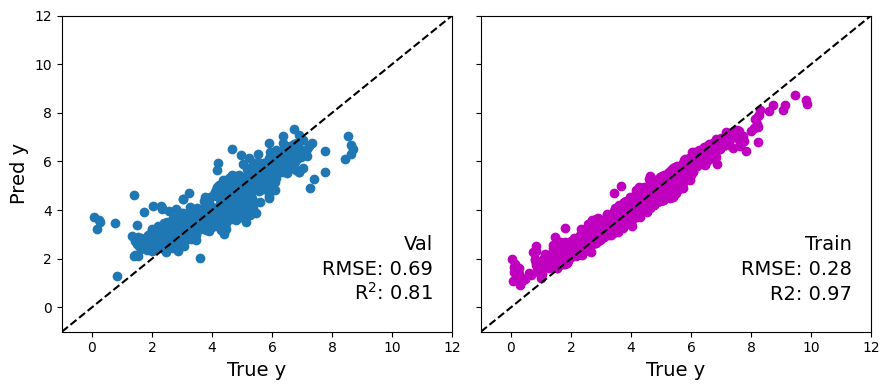

Root Mean squared error: 0.69
Coefficient of determination: 0.81


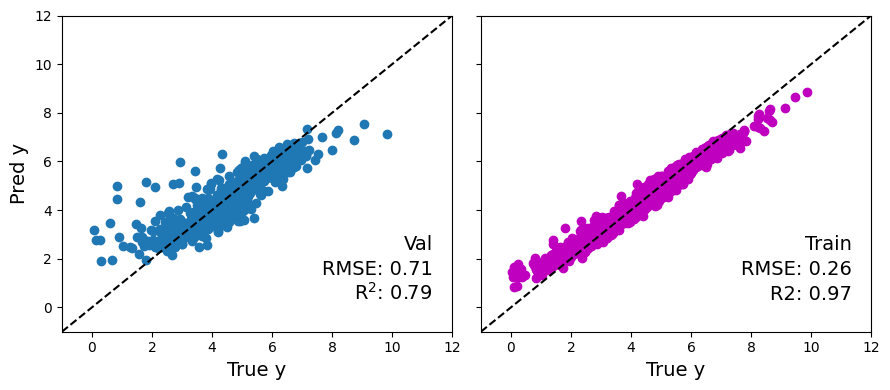

Root Mean squared error: 0.71
Coefficient of determination: 0.79


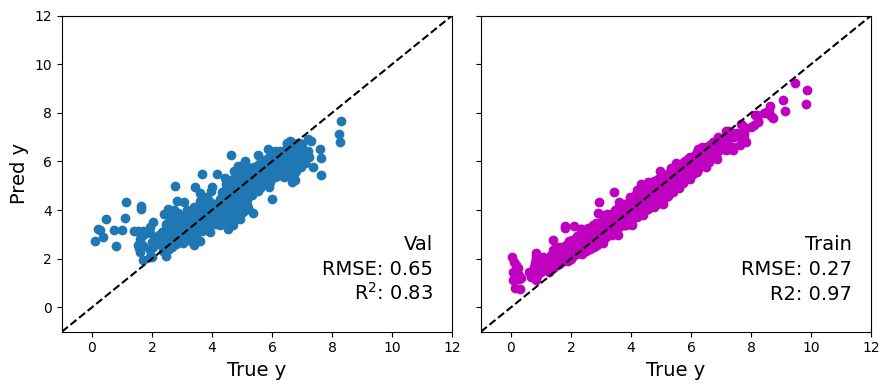

Root Mean squared error: 0.65
Coefficient of determination: 0.83


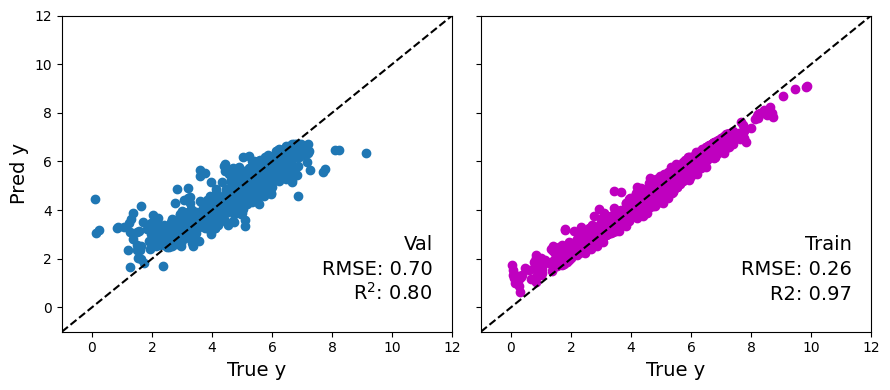

Root Mean squared error: 0.70
Coefficient of determination: 0.80


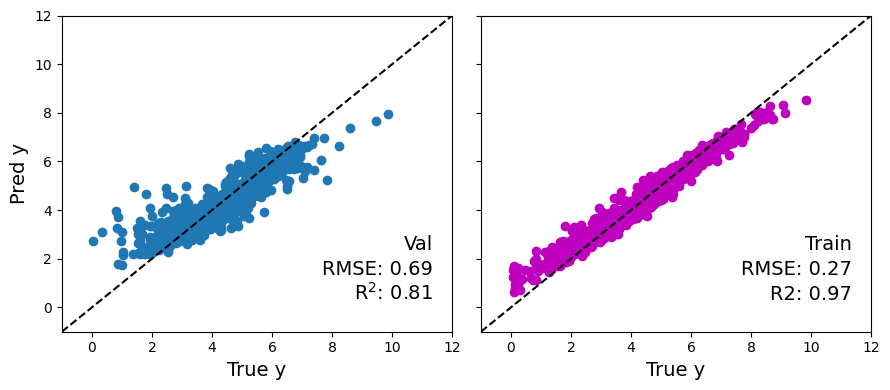

Root Mean squared error: 0.69
Coefficient of determination: 0.81


In [ ]:
rf_hyp_opt = RandomForestRegressor(n_estimators=50, random_state=42)
errors_rf_polybert = []

kf = KFold(n_splits=5)
for idx, (train, val) in enumerate(kf.split(X)):
    X_cv_train = X.values[train]
    X_cv_val = X.values[val]

    y_cv_train = y.values[train]
    y_cv_val = y.values[val]


    # Model fit and prediction
    model = rf_hyp_opt.fit(X_cv_train,y_cv_train)
    y_pred_val = model.predict(X_cv_val)
    y_pred_train = model.predict(X_cv_train)


    # Computing errors
    rmse_val = np.sqrt(mean_squared_error(y_cv_val, y_pred_val))
    rmse_train = np.sqrt(mean_squared_error(y_cv_train, y_pred_train))

    r2_val = r2_score(y_cv_val, y_pred_val)
    r2_train = r2_score(y_cv_train, y_pred_train)


    # Plot Parity plot
    polt_parity(y_cv_val,y_pred_val, y_cv_train,y_pred_train, label="Val", ylim = [-1,12])

    print("Root Mean squared error: %.2f" % rmse_val)
    print("Coefficient of determination: %.2f" % r2_val)

    error = {'kfold': idx+1,
             'rmse_train': rmse_train,
             'rmse_val': rmse_val,
             'r2_val': r2_val,
             'r2_train': r2_train}

    errors_rf_polybert.append(error)
errors_rf_polybert = pd.DataFrame(errors_rf_polybert)

In [ ]:
errors_rf_polybert[['rmse_val','r2_val']].mean()

,0
rmse_val,0.686644
r2_val,0.806736


#### Fine-tuning polyBERT

So far we treated polyBERT as a **frozen** feature extractor — its own weights never changed; we just read off its output and trained a separate RandomForest on top. **Fine-tuning** instead lets polyBERT's own weights adjust specifically for predicting Egc, by attaching a small regression head and continuing training end-to-end. This costs much more compute, which is where a GPU (e.g. Colab's free T4) are very useful.

CAUTION: 5-fold CV was computationally cheap for the frozen-embedding model above, since only a lightweight RandomForest was refit each fold. Fine-tuning the whole transformer 5 times over would be far more expensive for a live demo. So here we'll use a single 80/20 train/validation split instead — effectively one fold of a 5-fold CV. **This is a simplification for demo purposes.**

In [ ]:
from sklearn.model_selection import train_test_split

finetune_data = pdb.loc[~pdb['Egc'].isna(), ['smiles', 'Egc']]
finetune_data = finetune_data.sample(frac=1, random_state=42).reset_index(drop=True)
finetune_data.shape

(3379, 2)

In [ ]:
train_df, val_df = train_test_split(finetune_data, test_size=0.2, random_state=42)
train_df.shape, val_df.shape

((2703, 2), (676, 2))

#### Load polyBERT with a regression head

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

#tokenizer = AutoTokenizer.from_pretrained('kuelumbus/polyBERT')
#model_ft = AutoModelForSequenceClassification.from_pretrained(
#    'kuelumbus/polyBERT', num_labels=1, problem_type="regression"
#)


tokenizer = AutoTokenizer.from_pretrained('HAYDERphd/polyBERT')
model_ft = AutoModelForSequenceClassification.from_pretrained(
    'HAYDERphd/polyBERT', num_labels=1, problem_type="regression"
)



Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: HAYDERphd/polyBERT
Key                 | Status  | 
--------------------+---------+-
classifier.weight   | MISSING | 
classifier.bias     | MISSING | 
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


The warning above is expected: it tells us the regression head (`model_ft`'s final layer) was randomly initialized, since polyBERT was originally pretrained to predict masked tokens, not a numeric property. Everything below that head — the pretrained transformer body — keeps its pretrained weights.

In [ ]:
import torch
from torch.utils.data import Dataset

class PolymerDataset(Dataset):
    def __init__(self, smiles, targets, tokenizer, max_length=128):
        self.encodings = tokenizer(list(smiles), padding=True, truncation=True, max_length=max_length)
        self.targets = list(targets)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.targets[idx], dtype=torch.float)
        return item

train_dataset = PolymerDataset(train_df['smiles'], train_df['Egc'], tokenizer)
val_dataset = PolymerDataset(val_df['smiles'], val_df['Egc'], tokenizer)

#### Fine-tune with a short manual training loop


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_ft = model_ft.to(device)
optimizer = torch.optim.AdamW(model_ft.parameters(), lr=2e-5)
device

'cuda'

In [ ]:
n_epochs = 5

for epoch in range(n_epochs):
    # Training
    model_ft.train()
    train_losses = []
    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        optimizer.zero_grad()
        outputs = model_ft(**batch)
        loss = outputs.loss
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # Validation
    model_ft.eval()
    val_losses = []
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model_ft(**batch)
            val_losses.append(outputs.loss.item())

    print(f"Epoch {epoch+1}/{n_epochs} - train_loss: {np.mean(train_losses):.4f} - val_loss: {np.mean(val_losses):.4f}")

Epoch 1/5 - train_loss: 3.8137 - val_loss: 0.9597
Epoch 2/5 - train_loss: 0.4695 - val_loss: 0.4068
Epoch 3/5 - train_loss: 0.3216 - val_loss: 0.3876
Epoch 4/5 - train_loss: 0.2717 - val_loss: 0.4626
Epoch 5/5 - train_loss: 0.2128 - val_loss: 0.3761


In [ ]:
model_ft.eval()
val_preds = []
val_true = []
with torch.no_grad():
    for batch in val_loader:
        labels = batch.pop('labels')
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model_ft(**batch)
        val_preds.extend(outputs.logits.squeeze(-1).cpu().numpy())
        val_true.extend(labels.numpy())

rmse_val = np.sqrt(mean_squared_error(val_true, val_preds))
r2_val = r2_score(val_true, val_preds)

print("Root Mean squared error: %.2f" % rmse_val)
print("Coefficient of determination: %.2f" % r2_val)

errors_polybert_ft = pd.DataFrame([{'rmse_val': rmse_val, 'r2_val': r2_val}])

Root Mean squared error: 0.58
Coefficient of determination: 0.86


### 10. Graph-based prediction with a weighted, directed message-passing neural network (wD-MPNN)

**Graph neural networks (GNNs)** are another class of ML models that can learn polymer features from data. They work directly on the molecular graph — atoms as nodes, bonds as edges.

There's a catch specific to polymers, though. A repeat unit's graph — the same kind we've been drawing throughout this notebook — has two loose ends where the `[*]` connection points are. Nothing in that graph tells a standard GNN that the chain actually repeats forever; the two ends just look like dangling bonds.

Aldeghi & Coley (2022, *Chem. Sci.*, "A graph representation of molecular ensembles for polymer property prediction") solve this by linking the two ends of the repeat unit graph together with a weighted edge, effectively closing the loop so the graph represents the infinite repeating chain rather than an isolated fragment. For a copolymer with multiple monomer types, these edge weights also encode stoichiometry and chain architecture — but our dataset is homopolymers only, so we'll only need the simplest version of this idea: linking two ends together with full weight.

We'll use `polymer-chemprop`, the actual code released alongside that paper (an extension of the widely-used Chemprop library), rather than re-implementing the wD-MPNN ourselves.

#### Setup

In [ ]:
!pip install -q rdkit "git+https://github.com/coleygroup/polymer-chemprop.git"

  Preparing metadata (setup.py) ... done


This code was released in 2022. PyTorch has since changed a default setting in `torch.load` for security reasons, which breaks how this library reloads saved models. The cell below patches that one setting in the installed package; it doesn't change anything about the model itself.

In [ ]:
import chemprop, os
from sklearn.model_selection import train_test_split

chemprop_dir = os.path.dirname(chemprop.__file__)
utils_path = os.path.join(chemprop_dir, 'utils.py')

with open(utils_path, 'r') as f:
    contents = f.read()

contents = contents.replace(
    'torch.load(path, map_location=lambda storage, loc: storage)',
    'torch.load(path, map_location=lambda storage, loc: storage, weights_only=False)'
)

with open(utils_path, 'w') as f:
    f.write(contents)

#### Let's look at a few polymers first

Before converting the whole dataset, let's see what this extended format looks like for a handful of different polymers.

In [ ]:
sample_smiles = pdb['smiles'].sample(4, random_state=10).values
sample_smiles

array(['[*]CC(CC)O[*]', '[*]c1ccc2nc([*])oc2c1', '[*]CC(C)(CO[*])COCCC#N',
       '[*]CC1CCC(COC(=O)O[*])CC1'], dtype=object)

Each of these has exactly two `[*]` connection points (this is a homopolymer dataset — one repeat unit type per polymer). `polymer-chemprop` expects those points numbered (`[*:1]`, `[*:2]`), followed by the fraction of each fragment (`1.0`, since there's only one fragment here), followed by a rule describing how the fragments connect: `<1-2:1.0:1.0` means "connect point 1 to point 2, with full weight in both directions." That's exactly the "link the two ends together" trick above, written out as text.

In [ ]:
import re

def to_polymer_format(smiles):
    """
    Converts a homopolymer SMILES with two [*] connection points into
    the extended format expected by polymer-chemprop:
        [*:1]...[*:2]...|1.0|<1-2:1.0:1.0
    """
    count = [0]
    def label_star(match):
        count[0] += 1
        return f'[*:{count[0]}]'
    labeled = re.sub(r'\[\*\]', label_star, smiles)
    return f'{labeled}|1.0|<1-2:1.0:1.0'

for s in sample_smiles:
    print(to_polymer_format(s))

[*:1]CC(CC)O[*:2]|1.0|<1-2:1.0:1.0
[*:1]c1ccc2nc([*:2])oc2c1|1.0|<1-2:1.0:1.0
[*:1]CC(C)(CO[*:2])COCCC#N|1.0|<1-2:1.0:1.0
[*:1]CC1CCC(COC(=O)O[*:2])CC1|1.0|<1-2:1.0:1.0


This is the *homopolymer* special case of the paper's general format — for a copolymer with several monomers and non-trivial stoichiometry, the fraction and edge-weight fields would carry real (non-1.0) numbers instead of always being 1.0.

#### Scale up: convert the whole dataset and train

In [ ]:
gnn_data = pdb.loc[~pdb['Egc'].isna(), ['smiles', 'Egc']].copy()
gnn_data['smiles'] = gnn_data['smiles'].apply(to_polymer_format)
gnn_data = gnn_data.sample(frac=1, random_state=42).reset_index(drop=True)
gnn_data.shape

(3379, 2)

In [ ]:
from chemprop.rdkit import make_polymer_mol
from chemprop.features.featurization import tag_atoms_in_repeating_unit, remove_wildcard_atoms

def chemprop_can_process(polymer_string):
    """Runs chemprop's own molecule-construction pipeline on a polymer string
    and reports whether it succeeds, without actually training on it."""
    try:
        smiles_part = polymer_string.split('|')[0]
        fragment_weights = polymer_string.split('|')[1:-1]
        mol = make_polymer_mol(smiles_part, keep_h=False, add_h=False, fragment_weights=fragment_weights)
        rwmol = Chem.rdchem.RWMol(mol)
        rwmol, _ = tag_atoms_in_repeating_unit(rwmol)
        remove_wildcard_atoms(rwmol)
        return True
    except Exception:
        return False

valid_mask = gnn_data['smiles'].apply(chemprop_can_process)
n_dropped = (~valid_mask).sum()
print(f"Dropping {n_dropped} of {len(gnn_data)} polymers that this featurizer can't process "
      f"(usually fused aromatic ring systems it fails to re-kekulize after removing the [*] atoms).")

gnn_data = gnn_data[valid_mask].reset_index(drop=True)
gnn_data.shape

[08:09:12] Can't kekulize mol.  Unkekulized atoms: 17 18 19 22 25 26 27
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 17 18 19 22 25 26 27
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 13 14 15 18 21 22 23
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 13 14 15 18 21 22 23
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 19 20 21 24 27 28 29
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 19 20 21 24 27 28 29
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 20 21 22 25 28 29 30
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 20 21 22 25 28 29 30
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 7 8 9 12 15 16 17
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 7 8 9 12 15 16 17
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 12 13 14 17 20 21 22
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 12 13 14 17 20 21 22
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 11 12 13 16 19 20 21
[08:09:12] Can't kekulize mol.  Unkekulized atoms: 11 12 13 16 19 20 2

Dropping 94 of 3379 polymers that this featurizer can't process (usually fused aromatic ring systems it fails to re-kekulize after removing the [*] atoms).


[08:09:20] Can't kekulize mol.  Unkekulized atoms: 35 36 37 40 43 44 45
[08:09:20] Can't kekulize mol.  Unkekulized atoms: 35 36 37 40 43 44 45
[08:09:20] Can't kekulize mol.  Unkekulized atoms: 13 14 15 18 21 22 23
[08:09:20] Can't kekulize mol.  Unkekulized atoms: 13 14 15 18 21 22 23
[08:09:20] Can't kekulize mol.  Unkekulized atoms: 28 29 30 33 34 35 36 37 38
[08:09:20] Can't kekulize mol.  Unkekulized atoms: 28 29 30 33 34 35 36 37 38


(3285, 2)

As with polyBERT fine-tuning above, training this GNN 5 times over would be expensive, so we'll use a single 80/20 train/validation split.

In [ ]:
train_gnn, val_gnn = train_test_split(gnn_data, test_size=0.2, random_state=42)

train_gnn.to_csv('gnn_train.csv', index=False)
val_gnn.to_csv('gnn_val.csv', index=False)

train_gnn.shape, val_gnn.shape

((2628, 2), (657, 2))

#### Train

The `chemprop_train` command expects a designated "test" file to report a final score against; since we're deliberately not creating a separate held-out test set for this demo (see the note above), we point `--separate_test_path` at the same validation file — so the "test rmse" it prints is really just the validation performance, not a genuinely held-out result.

In [ ]:
!chemprop_train --data_path gnn_train.csv \
    --separate_val_path gnn_val.csv --separate_test_path gnn_val.csv \
    --dataset_type regression --polymer --save_dir gnn_ckpt \
    --epochs 5 --quiet

2628it [00:00, 89870.61it/s]
100% 2628/2628 [00:00<00:00, 151220.74it/s]
100% 2628/2628 [00:01<00:00, 1623.27it/s]
Fold 0
657it [00:00, 194142.44it/s]
100% 657/657 [00:00<00:00, 326461.05it/s]
100% 657/657 [00:00<00:00, 2900.42it/s]
657it [00:00, 336671.68it/s]
100% 657/657 [00:00<00:00, 565959.69it/s]
100% 657/657 [00:00<00:00, 190386.74it/s]
  0% 0/5 [00:00<?, ?it/s]
  0% 0/53 [00:00<?, ?it/s]
  2% 1/53 [00:00<00:24,  2.15it/s]
  4% 2/53 [00:00<00:14,  3.49it/s]
  6% 3/53 [00:00<00:11,  4.51it/s]
  8% 4/53 [00:00<00:09,  5.38it/s]
  9% 5/53 [00:01<00:12,  3.86it/s]
 11% 6/53 [00:01<00:10,  4.42it/s]
 13% 7/53 [00:01<00:09,  4.96it/s]
 15% 8/53 [00:01<00:08,  5.37it/s]
 17% 9/53 [00:01<00:07,  5.75it/s]
 19% 10/53 [00:02<00:07,  5.60it/s]
 21% 11/53 [00:02<00:07,  5.88it/s]
 23% 12/53 [00:02<00:07,  5.40it/s]
 25% 13/53 [00:02<00:08,  4.78it/s]
 26% 14/53 [00:02<00:07,  5.22it/s]
 28% 15/53 [00:03<00:08,  4.35it/s]
 30% 16/53 [00:03<00:08,  4.21it/s]
 32% 17/53 [00:03<00:09,  3.99it/s

#### Evaluate


In [ ]:
!chemprop_predict --test_path gnn_val.csv --checkpoint_dir gnn_ckpt --preds_path gnn_val_preds.csv

Loading training args
Setting molecule featurization parameters to default.
Loading data
657it [00:00, 217735.28it/s]
100% 657/657 [00:00<00:00, 288037.81it/s]
Validating SMILES
Test size = 657
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Predicting with an ensemble of 1 models
  0% 0/1 [00:00<?, ?it/s]Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pr

In [ ]:
val_preds = pd.read_csv('gnn_val_preds.csv')

rmse_val = np.sqrt(mean_squared_error(val_gnn['Egc'].values, val_preds['Egc'].values))
r2_val = r2_score(val_gnn['Egc'].values, val_preds['Egc'].values)

print("Root Mean squared error: %.2f" % rmse_val)
print("Coefficient of determination: %.2f" % r2_val)

errors_gnn = pd.DataFrame([{'rmse_val': rmse_val, 'r2_val': r2_val}])

Root Mean squared error: 0.59
Coefficient of determination: 0.85


### 11. Comparing all models

We've now built five different ways to predict Egc: two classical fingerprint/descriptor-based models, a graph neural network, and a transformer used two ways (frozen and fine-tuned). Let's put them side by side.

One important caveat before looking at the table: this comparison isn't perfectly apples-to-apples. The fingerprint- and descriptor-based models above, along with the frozen-embedding polyBERT model, all used full 5-fold cross-validation. The GNN and fine-tuned polyBERT model used a single 80/20 train/validation split instead.

In [ ]:
comparison = pd.DataFrame([
    {'model': 'Morgan fingerprint + RF', 'representation': 'Fingerprint', 'evaluation': '5-fold CV',
     'rmse': errors_rf_mfp['rmse_val'].mean(), 'r2': errors_rf_mfp['r2_val'].mean()},
    {'model': 'Morgan + descriptors + RF', 'representation': 'Fingerprint + descriptors', 'evaluation': '5-fold CV',
     'rmse': errors_rf_molfp['rmse_val'].mean(), 'r2': errors_rf_molfp['r2_val'].mean()},
    {'model': 'polyBERT (frozen) + RF', 'representation': 'Transformer embedding', 'evaluation': '5-fold CV',
     'rmse': errors_rf_polybert['rmse_val'].mean(), 'r2': errors_rf_polybert['r2_val'].mean()},
    {'model': 'polyBERT (fine-tuned)', 'representation': 'Transformer (fine-tuned)', 'evaluation': 'single 80/20 split',
     'rmse': errors_polybert_ft['rmse_val'].mean(), 'r2': errors_polybert_ft['r2_val'].mean()},
    {'model': 'wD-MPNN (GNN)', 'representation': 'Molecular graph', 'evaluation': 'single 80/20 split',
     'rmse': errors_gnn['rmse_val'].mean(), 'r2': errors_gnn['r2_val'].mean()},
])
comparison

,model,representation,evaluation,rmse,r2
0,Morgan fingerprint + RF,Fingerprint,5-fold CV,0.642851,0.830062
1,Morgan + descriptors + RF,Fingerprint + descriptors,5-fold CV,0.536898,0.881156
2,polyBERT (frozen) + RF,Transformer embedding,5-fold CV,0.686644,0.806736
3,polyBERT (fine-tuned),Transformer (fine-tuned),single 80/20 split,0.583042,0.859308
4,wD-MPNN (GNN),Molecular graph,single 80/20 split,0.587818,0.847759


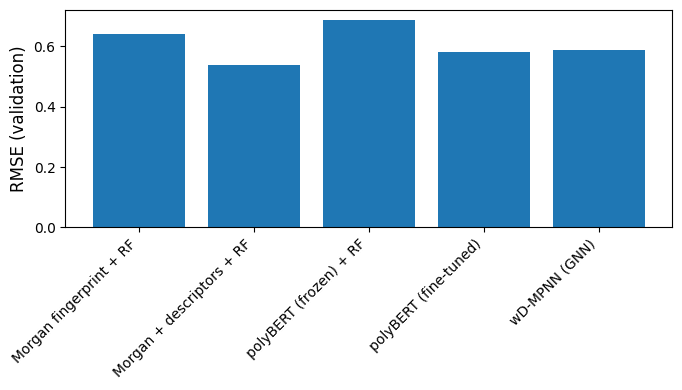

In [ ]:
plt.figure(figsize=(7,4))
plt.bar(comparison['model'], comparison['rmse'])
plt.ylabel('RMSE (validation)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Future exercises
1. Repeat the GNN and/or polyBERT sections on Egb instead of Egc. Does the ranking of models change?
2. Both new sections used a single train/validation split rather than 5-fold CV, for compute reasons. Extend it to proper 5-fold CV (or at least add a genuine held-out test set) — how much do the numbers move?
3. Extend the GNN or fine-tuned transformer to the multitask Egb+Egc setup suggested in the earlier "Future Exercise"?
4. Which model would you actually deploy for polymer discovery, and why?